# Data-Centric Programming Study Project: Weather and Air Pollution Analysis

Public portfolio version of a group study project. Personal data, API credentials and internal course material have been removed.

This notebook analyses hourly weather and air pollution data for selected Swiss cities. The project was completed as a group assignment in a data-centred programming study project in the BSc Applied Digital Life Sciences at Zurich University of Applied Sciences (ZHAW).

The analysis focuses on Zurich, Basel, Lucerne, Lugano, St. Gallen and Geneva for the period from June 2024 to May 2025. Weather data such as temperature, wind speed and rainfall are combined with air pollution data for PM2.5 and PM10. The data is retrieved via OpenWeather APIs, cached locally, merged by timestamp and analysed using descriptive statistics, correlation matrices, boxplots, scatterplots and time-series visualisations.

The objective of the project is not to prove strict causality, but to identify observable patterns between meteorological conditions and particulate matter concentrations. The results indicate that temperature and wind speed are more clearly associated with changes in PM levels than rainfall, while PM2.5 and PM10 show a strong positive relationship across the analysed cities.

## Fragestellung

Wie hängen meteorologische Faktoren wie Temperatur, Windgeschwindigkeit und Niederschlag mit den Feinstaubkonzentrationen PM2.5 und PM10 in ausgewählten Schweizer Städten zusammen?

## Einleitung

Öffentliche Portfolio-Version einer Gruppenarbeit. Persönliche Daten, API-Schlüssel und internes Kursmaterial wurden entfernt.

Dieses Notebook untersucht stündliche Wetter- und Luftqualitätsdaten für ausgewählte Schweizer Städte. Die Gruppenarbeit wurde im Rahmen eines data-centred programming study project im BSc Applied Digital Life Sciences an der Zürcher Hochschule für Angewandte Wissenschaften (ZHAW) erstellt.

Im Zentrum steht die Frage, ob und wie meteorologische Faktoren wie Temperatur, Windgeschwindigkeit und Niederschlag mit den Feinstaubkonzentrationen PM2.5 und PM10 zusammenhängen. Feinstaub gehört zu den wichtigsten Luftschadstoffen in urbanen Räumen. PM steht für *Particulate Matter*; die Zahl beschreibt den maximalen Partikeldurchmesser in Mikrometern. PM2.5 umfasst besonders kleine Partikel, die tief in die Atemwege eindringen können, während PM10 auch gröbere Partikel enthält.

Untersucht werden Zürich, Basel, Luzern, Lugano, St. Gallen und Genf im Zeitraum vom 1. Juni 2024 bis zum 9. Mai 2025. Die Daten werden über die OpenWeather APIs abgerufen, lokal zwischengespeichert, nach Zeitstempel zusammengeführt und anschliessend explorativ analysiert.

Das Ziel der Analyse ist nicht der Nachweis strenger Kausalität. Vielmehr werden beobachtbare Muster, saisonale Verläufe und statistische Zusammenhänge zwischen Wetterbedingungen und Feinstaubkonzentrationen sichtbar gemacht.


### Vorbereitung der Umgebung und Laden des API-Schlüssels

#### Wichtige Hinweise zur API-Verwendung

Für die Abfrage der Daten wird ein persönlicher API-Key von OpenWeather benötigt. Der verwendete Zugang muss sowohl den Zugriff auf historische Wetterdaten als auch auf historische Luftqualitätsdaten ermöglichen. Weitere Informationen zu den verfügbaren API-Plänen finden sich auf der Pricing-Seite von OpenWeather: [Pricing](https://openweathermap.org/price)

Die Datei `secret_api_key.csv` ist nicht Teil des öffentlichen Repositorys und sollte in `.gitignore` eingetragen sein. Für die Reproduzierbarkeit kann stattdessen eine Beispieldatei `secret_api_key.example.csv` bereitgestellt werden.


In [1]:
from IPython.display import display, HTML
from datetime import datetime, timezone
from dataclasses import dataclass

import os
import re
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.ion()

os.makedirs("data", exist_ok=True)
os.makedirs("plots", exist_ok=True)

# The file secret_api_key.csv must contain one column named "APIKey".
api_df = pd.read_csv("secret_api_key.csv", sep=";", encoding="utf-8")
API_KEY = api_df.loc[0, "APIKey"]


## Daten-Pipeline

### Abrufen geografischer Koordinaten per API

In [3]:
@dataclass
class Coordinate:
    latitude: float
    longitude: float


def fetch_coordinates(city_name: str) -> Coordinate:
    url = "https://api.openweathermap.org/geo/1.0/direct"

    parameter = {
        "q": city_name,
        "appid": API_KEY,
        "limit": 1
    }

    response = requests.get(url, params=parameter)

    if response.status_code != 200:
        raise ValueError(f"Fehler {response.status_code}: {response.text}")

    data = response.json()

    if not data:
        raise ValueError(f"Keine Koordinaten gefunden für {city_name}")

    latitude = data[0]["lat"]
    longitude = data[0]["lon"]

    return Coordinate(latitude, longitude)

#### Beschreibung des Code Blocks
- `Coordinate`: enthält die zwei Attribute `latitude` (Breitengrad) und `longitude` (Längengrad). Diese Klasse dient als strukturierter Rückgabetyp für geografische Koordinaten.
- `fetch_coordinates(city_name)` sendet eine Anfrage an die [Geocoding-API von OpenWeatherMap](https://openweathermap.org/api/geocoding-api) um die geografischen Koordinaten einer Stadt anhand ihres Namens zu ermitteln.

### Historische Wetterdaten abrufen

In [4]:
def fetch_weather_data_from_api(coordinates: Coordinate, from_date_unix: int, to_date_unix: int) -> pd.DataFrame:
    url = "https://history.openweathermap.org/data/2.5/history/city"

    parameter = {
        "lat": coordinates.latitude,
        "lon": coordinates.longitude,
        "type": "hour",
        "start": from_date_unix,
        "end": to_date_unix,
        "appid": API_KEY,
        "units": "metric"
    }

    response = requests.get(url, params=parameter)

    if response.status_code == 200:
        data = response.json()

        results = pd.DataFrame()
        for entry in data.get("list", []):
          row = pd.DataFrame([{
              "timestamp": entry["dt"],
              "temperature": entry["main"]["temp"],
              "wind_speed": entry["wind"]["speed"],
              "rain": entry.get("rain", {}).get("1h", 0)
          }])

          results = pd.concat([results, row], ignore_index=True)
        
        return results
            
    else:
        raise ValueError(f"Fehler {response.status_code}: {response.text}")


def fetch_weather_data(city: str, from_date_unix: int, to_date_unix: int) -> pd.DataFrame:
    week_seconds = 604_800

    coordinates = fetch_coordinates(city)
    
    weather_df = pd.DataFrame()

    current_start = from_date_unix
    while current_start < to_date_unix:
        current_end = min(current_start + week_seconds, to_date_unix)
        
        weather_chunk = fetch_weather_data_from_api(coordinates, current_start, current_end)
        weather_df = pd.concat([weather_df, weather_chunk], ignore_index=True)

        current_start += week_seconds

    weather_df["timestamp"] = pd.to_datetime(weather_df["timestamp"], unit="s")

    return weather_df

#### Beschreibung des Code Blocks
- `fetch_weather_data_from_api`: holt stündliche Wetterdaten aus der [historischen OpenWeatherMap-API](https://openweathermap.org/history) für einen bestimmten Zeitraum und eine gegebene Koordinate.
- Das History OpenWeatherMap-API lässt nur einen begrenzten Zeitraum (1 Woche) pro Anfrage zu. `fetch_weather_data` führt mehrere Abrufe an das API aus und verschiebt pro Abruf die Zeit um 1 Woche. Zudem führt sie eine Koordinatenabfrage für eine Stadt und die Umwandlung des Unix Zeitstempels in ein `datetime`-Format aus.

### Luftverschmutzungsdaten abrufen

In [5]:
def fetch_emission_data_from_api(coordinates: Coordinate, from_date_unix: int, to_date_unix: int) -> pd.DataFrame:
    url = "http://api.openweathermap.org/data/2.5/air_pollution/history"

    parameter = {
        "lat": coordinates.latitude,
        "lon": coordinates.longitude,
        "start": from_date_unix,
        "end": to_date_unix,
        "appid": API_KEY
    }

    response = requests.get(url, params=parameter)

    if response.status_code == 200:
        data = response.json()
    
        results = pd.DataFrame()
        for entry in data.get("list", []):
            row = pd.DataFrame([{
                "timestamp": entry["dt"],
                "pm_fine": entry["components"]["pm2_5"],
                "pm_coarse": entry["components"]["pm10"]
            }])

            results = pd.concat([results, row], ignore_index=True)
        
        return results

    else:
        raise ValueError(f"Fehler {response.status_code}: {response.text}")


def fetch_emission_data(city: str, from_date_unix: int, to_date_unix: int) -> pd.DataFrame:
    coordinates = fetch_coordinates(city)

    emission_df = fetch_emission_data_from_api(coordinates, from_date_unix, to_date_unix)
    emission_df["timestamp"] = pd.to_datetime(emission_df["timestamp"], unit="s")

    return emission_df


#### Beschreibung des Code Blocks
- `fetch_emission_data_from_api` holt aus dem OpenWeatherMap [Air Pollution History API von OpenWeather](https://openweathermap.org/api/air-pollution) historische Emissionsdaten eines Standorts im angegebenen Zeitraum ab.
- `fetch_emission_data`: Hilfsfunktion, welche die Koordinatenabfrage für eine Stadt, API-Abruf für die Emissionsdaten und die Umwandlung des Unix Zeitstempels in ein `datetime`-Format bringt.

### Daten lokal speichern, wiederverwenden und anzeigen

In [6]:
WEATHER_DATA_TYPE = "weather"
EMISSION_DATA_TYPE = "emission"

def load_data_from_disk_or(city, from_date_unix, to_date_unix, data_type, or_fn) -> pd.DataFrame:
    file_name = make_safe_filename(city, data_type)+ ".pkl"
    try:
        return pd.read_pickle(file_name)
    
    except FileNotFoundError: 
        data = or_fn(city, from_date_unix, to_date_unix)
        data.to_pickle(file_name)
        return data


def make_safe_filename(city: str, data_type: str, folder: str = "data"):
    umlaut_map = {
        "ä": "ae", "ö": "oe", "ü": "ue",
        "Ä": "Ae", "Ö": "Oe", "Ü": "Ue",
        "ß": "ss"
    }
    for umlaut, replacement in umlaut_map.items():
        city = city.replace(umlaut, replacement)

    safe_city = re.sub(r"[^\w]+", "_", city.lower()).strip("_")
    return f"{folder}/{safe_city}_{data_type}"


def show_city_data_summary(city: str, weather_df: pd.DataFrame, emission_df: pd.DataFrame, folder: str = "data"):
    display(HTML(f"""
        <div style="margin-bottom: 50px;">
            <h2 style="margin-bottom: 10px;">{city}</h2>
            <div style="display: flex; gap: 40px;">
                <div>
                    <h3>Wetterdaten</h3>
                    {weather_df.describe().to_html()}
                </div>
                <div>
                    <h3>Emissionsdaten</h3>
                    {emission_df.describe().to_html()}
                </div>
            </div>
        </div>
    """))

#### Beschreibung des Code Blocks
- `load_data_from_disk_or`: Diese Funktion sorgt dafür, dass bereits abgerufene Daten lokal zwischengespeichert werden, um wiederholte API-Abfragen zu vermeiden.
- `make_safe_filename`: Diese Hilfsfunktion erstellt einen sicheren Dateinamen für die erstellten lokalen Daten um einen konsistenten Dateipfad sicherzustellen.
- `show_city_data_summary`: Hier wird eine visuelle Zusammenfassung der Wetter und Emissionsdaten für eine Stadt erzeugt. Somit können die Daten überprüft werden.

### Daten für mehrere Städte laden und anzeigen

In [7]:
from_date_unix = int(datetime(2024, 6, 1, tzinfo=timezone.utc).timestamp())
to_date_unix = int(datetime(2025, 5, 9, tzinfo=timezone.utc).timestamp())

cities = ["Zurich", "Basel", "Lucerne", "Lugano", "St. Gallen", "Geneva"]
weather_data = list(map(lambda city: load_data_from_disk_or(city, from_date_unix, to_date_unix, WEATHER_DATA_TYPE, fetch_weather_data), cities))
emission_data = list(map(lambda city: load_data_from_disk_or(city, from_date_unix, to_date_unix, EMISSION_DATA_TYPE, fetch_emission_data), cities))

for (city, weather_df, emission_df) in zip(cities, weather_data, emission_data):
    show_city_data_summary(city, weather_df, emission_df)


#### Beschreibung des Code Blocks
1. Es wird ein Zeitraum definiert vom 1. Juni 2024 bis zum 9. Mai 2025. Der Grund für diesen Zeitraum ist, dass das History OpenWeather- API nur Abfragen von bis zu einem Jahr zulässt.
2. Die Städte von der Fragestellung wurden definiert.
3. Für jede Stadt wird zuerst versucht, die Daten lokal zu laden und falls sie nicht vorhanden sind, werden die Daten via API geladen und gespeichert.
4. Generierung von der Datenübersicht pro Stadt.


### Plausibilität der Daten

#### Wetterdaten

| Stadt       | Temp. (°C) Min–Max | Wind (m/s) Max | Regen (mm/h) Max | Plausibilität |
|-------------|--------------------|----------------|------------------|----------------|
| Zurich      | -5.7 – 33.7        | 19.0           | 38.7             | Realistisch, starke Windböen & Starkregen möglich |
| Basel       | -5.4 – 34.8        | 12.4           | 9.5              | Unauffällig, typische Verteilung |
| Lucerne     | -5.2 – 33.0        | 10.8           | 16.8             | Plausibel, keine Extremwerte |
| Lugano      | -3.6 – 34.6        | 12.4           | 31.6             | Subtropisches Klima erklärt hohe Regenwerte |
| St. Gallen  | -7.8 – 31.0        | 11.3           | 126.0            | Sehr hoher Regen-Max, kann auf starker Regenschauer oder möglicher Ausreisser hindeuten |
| Geneva      | -4.8 – 33.9        | 13.9           | 36.5             | Starkregen|


#### Emissionsdaten (PM fine / coarse in µg/m³)

| Stadt       | PM fine Mean | PM fine Max | PM coarse Max | Plausibilität |
|-------------|--------------|-------------|----------------|----------------|
| Zurich      | 17.1         | 147.0       | 156.5          | Sehr hoher Max-Wert |
| Basel       | 13.7         | 117.5       | 124.3          | Hoher Peak, aber in Grossstadt realistisch |
| Lucerne     | 9.3          | 110.3       | 119.2          | Werte in typischem Bereich |
| Lugano      | 18.1         | 134.5       | 141.5          | Werte relativ hoch, evtl. Verkehrseinfluss |
| St. Gallen  | 13.0         | 95.5        | 101.0          | Plausibel für kleinere Stadt |
| Geneva      | 17.7         | 151.6       | 160.2          | Sehr hohe Maxima – möglicher Verkehrseinfluss/Flughafennähe |


#### Fazit

- Die Wetterdaten sind plausibel, mit realistischen Verteilungen.
- Es zeigt sich jedoch, dass die Emissionsdaten nicht gleichviele Zeilen enthalten wie die Wetterdaten. Nach einem "left" side Merge wurden die leeren Zellen überprüft und der timestamp bildete ein klares Bild, dass Emissionsdaten von ganzen Tagen fehlen. Dies wurde auch noch manuell überprüft um einen möglichen Fehler bei der API-Abfrage auszuschliessen. Es zeigte sich jedoch, dass es für gewisse Tage keine aufgezeichnete Emissionsdaten gibt. Darum wurde entschieden, dass die beiden Dataframes mit einem "inner" Merge weiterbehandelt werden und somit die leeren Zeilen zu entfernen

### Destrukturierung des Timestamps und Datenpipeline für die Datenaufarbeitung

In [8]:
def destructure_timestamp(df):
    df["month"] = df["timestamp"].dt.month_name().astype("category")
    df["weekday"] = df["timestamp"].dt.day_name().astype("category")
    df["hour"] = df["timestamp"].dt.hour
    return df


def apply_data_pipeline(weather_df, emission_df):
    df = pd.merge(weather_df, emission_df, on="timestamp", how="inner")
    df = destructure_timestamp(df)
    return df

In [9]:
merged = list(map(lambda x: apply_data_pipeline(x[0], x[1]), zip(weather_data, emission_data)))
[df_zurich, df_basel, df_lucerne, df_lugano, df_st_gallen, df_geneva] = merged
df_zurich

,timestamp,temperature,wind_speed,wind_direction,rain,pm_fine,pm_coarse,month,weekday,hour
0,2024-05-31 22:00:00,10.21,4.02,221,0.42,1.00,1.24,May,Friday,22
1,2024-05-31 23:00:00,10.26,6.26,219,0.52,0.87,1.07,May,Friday,23
2,2024-06-01 00:00:00,10.11,2.68,220,0.75,0.81,0.98,June,Saturday,0
3,2024-06-01 01:00:00,10.29,2.24,224,0.32,0.78,0.94,June,Saturday,1
4,2024-06-01 02:00:00,10.04,5.36,225,0.26,0.74,0.90,June,Saturday,2
...,...,...,...,...,...,...,...,...,...,...
7930,2025-05-08 18:00:00,13.37,5.14,40,0.00,3.93,4.05,May,Thursday,18
7931,2025-05-08 19:00:00,12.20,4.12,50,0.00,3.89,4.01,May,Thursday,19
7932,2025-05-08 20:00:00,11.08,3.09,30,0.00,3.88,4.00,May,Thursday,20
7933,2025-05-08 21:00:00,10.45,3.60,40,0.00,3.81,3.92,May,Thursday,21


#### Beschreibung des Code Blocks
Hier werden die Wetterdaten und Emissionsdaten für jede Stadt zusammengeführt. Anschliessend wird die Liste in die einzelnen DataFrames für jede Stadt zerlegt für eine mögliche Analyse der einzelnen Städte.  
Als Beispiel wird das DataFrame Zürich angezeigt.

### Überprüfen der Datentypen von der finalen DataFrame

In [10]:
df_zurich.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7935 entries, 0 to 7934
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       7935 non-null   datetime64[ns]
 1   temperature     7935 non-null   float64       
 2   wind_speed      7935 non-null   float64       
 3   wind_direction  7935 non-null   int64         
 4   rain            7935 non-null   float64       
 5   pm_fine         7935 non-null   float64       
 6   pm_coarse       7935 non-null   float64       
 7   month           7935 non-null   category      
 8   weekday         7935 non-null   category      
 9   hour            7935 non-null   int32         
dtypes: category(2), datetime64[ns](1), float64(5), int32(1), int64(1)
memory usage: 481.3 KB


## Data Analysis

### Konstanten

In [11]:
PM_MIN = -10
PM_MAX = 160

WIND_MIN = -2
WIND_MAX = 20

RAIN_MIN = -2
RAIN_MAX = 45

TEMP_MIN = -10
TEMP_MAX = 40

WINDOW_SIZE = 15

### Korrelationsmatrix

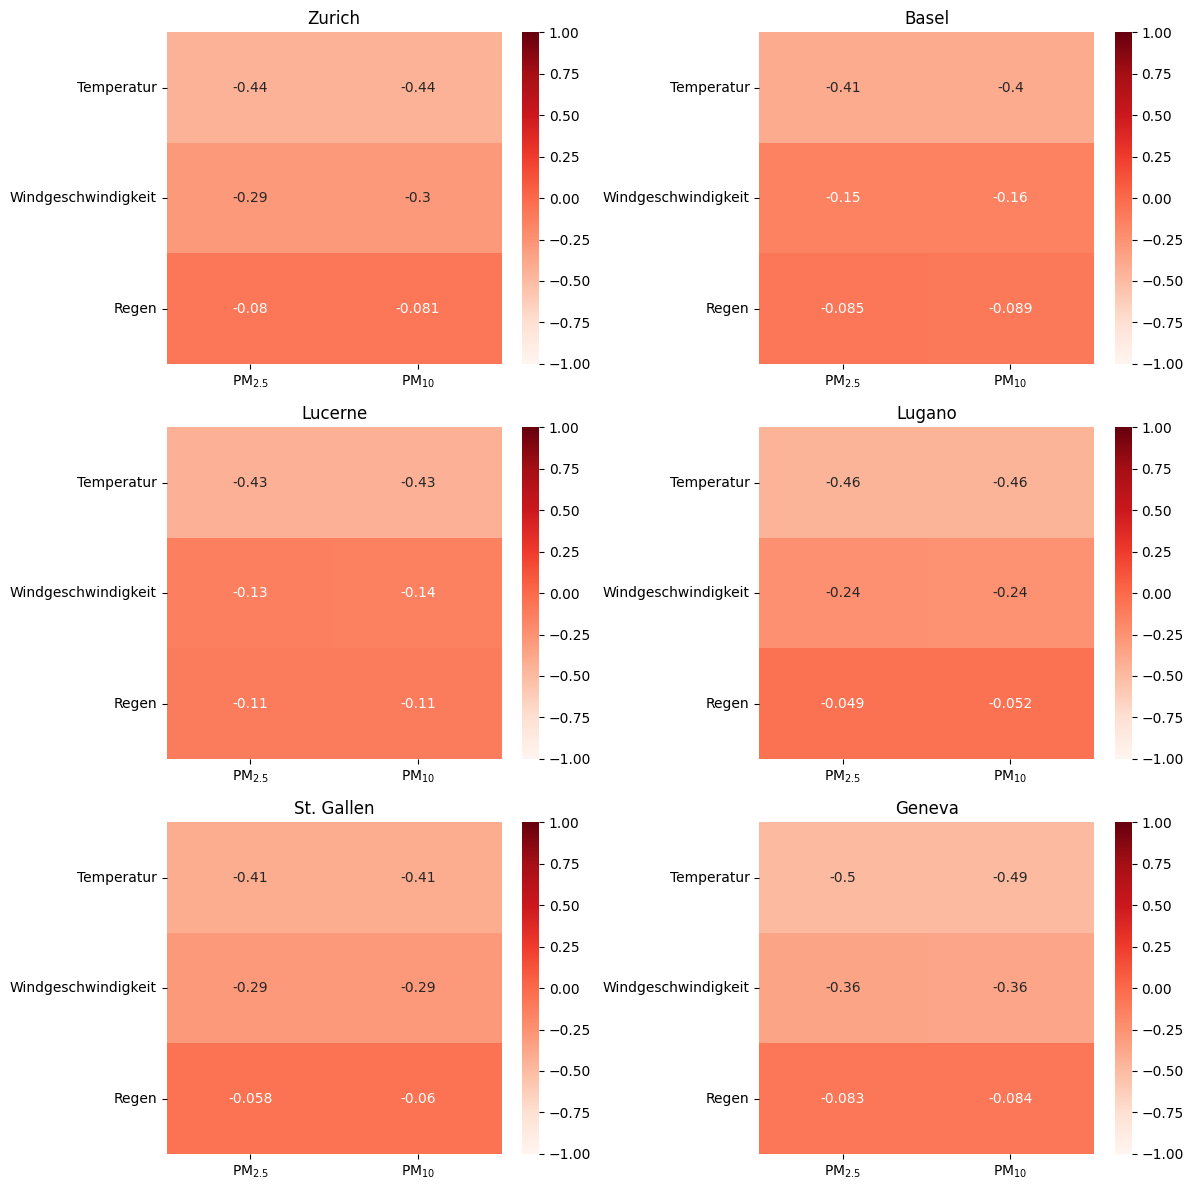

In [12]:
weather_vars = ["temperature", "wind_speed", "rain"]
pm_vars = ["pm_fine", "pm_coarse"]

label_map = {
    "temperature": "Temperatur",
    "wind_speed": "Windgeschwindigkeit",
    "rain": "Regen",
    "pm_fine": "PM$_{2.5}$",
    "pm_coarse": "PM$_{10}$"
}

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, city, df in zip(axes, cities, merged):
    corr = df[weather_vars + pm_vars].corr().loc[weather_vars, pm_vars]

    sns.heatmap(
        corr,
        annot=True,
        cmap="Reds",
        vmin=-1,
        vmax=1,
        xticklabels=[label_map.get(var, var) for var in pm_vars],
        yticklabels=[label_map.get(var, var) for var in weather_vars],
        ax=ax,
        cbar=True
    )
    ax.set_title(city)

plt.tight_layout()
plt.savefig("plots/correlation_heatmaps_3x2.jpg", format="jpg", dpi=300, bbox_inches="tight")
plt.show()


#### Beschreibung der Korrelationsmatrix

Die nachfolgende Korrelationsanalyse untersucht den Zusammenhang zwischen den Feinstaubkonzentrationen (PM<sub>2.5</sub> und PM<sub>10</sub>) und ausgewählten meteorologischen Variablen (Temperatur, Windgeschwindigkeit und Niederschlag) für verschiedene Schweizer Städte.

Die Ergebnisse zeigen über alle Städte hinweg ein konsistentes Muster:

- **Niederschlag** weist nahezu keine Korrelation mit den Konzentrationen von PM<sub>2.5</sub> und PM<sub>10</sub> auf. Dies lässt vermuten, dass Regenereignisse im betrachteten Zeitraum nur einen geringen Einfluss auf die Feinstaubbelastung hatten.
- **Windgeschwindigkeit** korreliert schwach negativ mit den Feinstaubwerten. Dieser Zusammenhang deutet darauf hin, dass eine erhöhte Luftbewegung zu einer Verdünnung oder Verfrachtung von Feinstaubpartikeln führen kann, wodurch deren Konzentration in Bodennähe reduziert wird.
- **Temperatur** zeigt einen moderaten negativen Zusammenhang mit beiden Feinstaubfraktionen. Diese Korrelation legt nahe, dass höhere Temperaturen mit geringeren PM-Konzentrationen einhergehen. Ein möglicher Erklärungsansatz hierfür ist ein saisonaler Effekt: In den wärmeren Monaten begünstigen meteorologische Bedingungen wie stärkere vertikale Luftdurchmischung und geringere Heizemissionen eine bessere Luftqualität.

Insgesamt lässt sich schlussfolgern, dass von den untersuchten Wettervariablen die Temperatur den stärksten Einfluss auf die Feinstaubbelastung ausübt, während Niederschlag kaum eine Rolle spielt.


### Städtevergleich

In [13]:
df_pm_zurich = df_zurich[["timestamp", "pm_fine", "pm_coarse"]]
df_pm_zurich

,timestamp,pm_fine,pm_coarse
0,2024-05-31 22:00:00,1.00,1.24
1,2024-05-31 23:00:00,0.87,1.07
2,2024-06-01 00:00:00,0.81,0.98
3,2024-06-01 01:00:00,0.78,0.94
4,2024-06-01 02:00:00,0.74,0.90
...,...,...,...
7930,2025-05-08 18:00:00,3.93,4.05
7931,2025-05-08 19:00:00,3.89,4.01
7932,2025-05-08 20:00:00,3.88,4.00
7933,2025-05-08 21:00:00,3.81,3.92


#### Beschreibung der Tabelle

Die folgende Tabelle zeigt die Konzentrationen der beiden Feinstaubfraktionen PM<sub>2.5</sub> (`pm_fine`) und PM<sub>10</sub> (`pm_coarse`) für die Stadt Zürich. Es ist ersichtlich, dass sich die Werte beider Partikelfraktionen über den gesamten Zeitraum hinweg in einem ähnlichen Bereich bewegen und nur geringe Unterschiede aufweisen.

Aufgrund dieser hohen Ähnlichkeit wurde entschieden, für die nachfolgenden Analysen und Visualisierungen ausschliesslich die PM<sub>2.5</sub>-Konzentration zu berücksichtigen. Diese Entscheidung dient der Reduktion der grafischen Komplexität und ermöglicht eine klarere und fokussierte Darstellung der Ergebnisse.


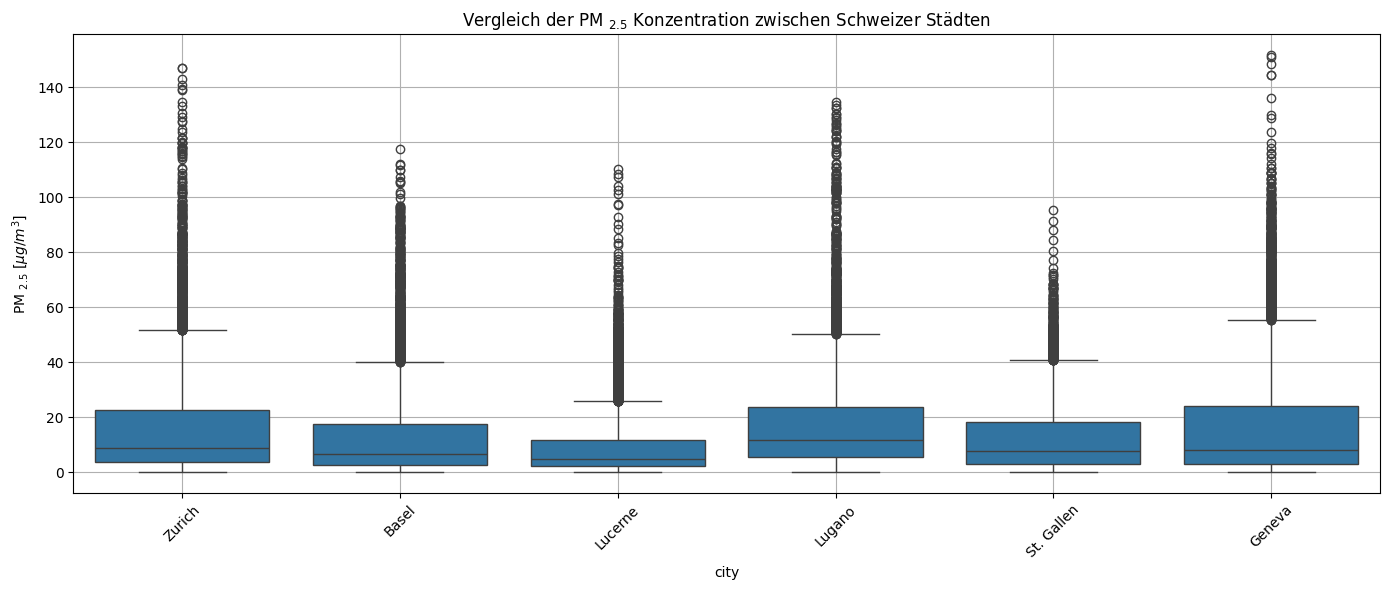

In [14]:
merged_df = pd.concat([df.assign(city=city) for df, city in zip(merged, cities)], ignore_index=True)

plt.figure(figsize=(14, 6))
sns.boxplot(data=merged_df, x="city", y="pm_fine")
plt.title(r"Vergleich der PM $_{2.5}$ Konzentration zwischen Schweizer Städten")
plt.ylabel(r"PM $_{2.5}$ [$\mu g/m^3$]")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.savefig("plots/boxplot_pm2_5_city_comparison.jpg", format="jpg", dpi=300, bbox_inches="tight")
plt.show()


#### Beschreibung des PM<sub>2.5</sub>-Boxplots

Die folgende Grafik zeigt einen Vergleich der stündlichen PM<sub>2.5</sub>-Konzentrationen in sechs ausgewählten Schweizer Städten anhand von Boxplots. Diese Darstellungsform ermöglicht eine übersichtliche Einschätzung der Verteilung, der zentralen Tendenz, der Streuung sowie möglicher Extremwerte der Feinstaubbelastung.

Die Medianwerte der stündlichen PM<sub>2.5</sub>-Konzentrationen liegen in den meisten Städten im Bereich von etwa 8 bis 10 µg/m³; Luzern weist mit ungefähr 5 bis 6 µg/m³ den niedrigsten Median auf. Da es sich hierbei um Medianwerte stündlicher Messungen handelt, sind sie nicht direkt mit WHO-Richtwerten vergleichbar, welche sich auf Jahresmittelwerte beziehungsweise 24-Stunden-Mittelwerte beziehen.

Trotz relativ moderater zentraler Werte zeigen alle Städte deutliche Ausreisser nach oben. Diese Ausreisser deuten auf einzelne Stunden oder Episoden mit stark erhöhter Feinstaubbelastung hin. Besonders ausgeprägte Spitzenwerte sind in Zürich, Lugano und Genf zu beobachten, teilweise mit Konzentrationen von über 140 µg/m³.

Die Städte Zürich, Basel, Lugano, St. Gallen und Genf weisen vergleichbare zentrale Werte auf, während Luzern insgesamt tiefere PM<sub>2.5</sub>-Konzentrationen zeigt. Eine grössere Streuung der mittleren 50 % der Werte ist insbesondere in Lugano und Genf erkennbar, was auf stärkere Schwankungen der Feinstaubbelastung hinweist.

Mögliche Ursachen für erhöhte PM<sub>2.5</sub>-Werte sind meteorologische Bedingungen, Verkehr, Heizquellen, lokale Emissionssituationen sowie der Ferntransport von Schadstoffen. Aus den Boxplots allein lässt sich jedoch keine kausale Ursache ableiten.


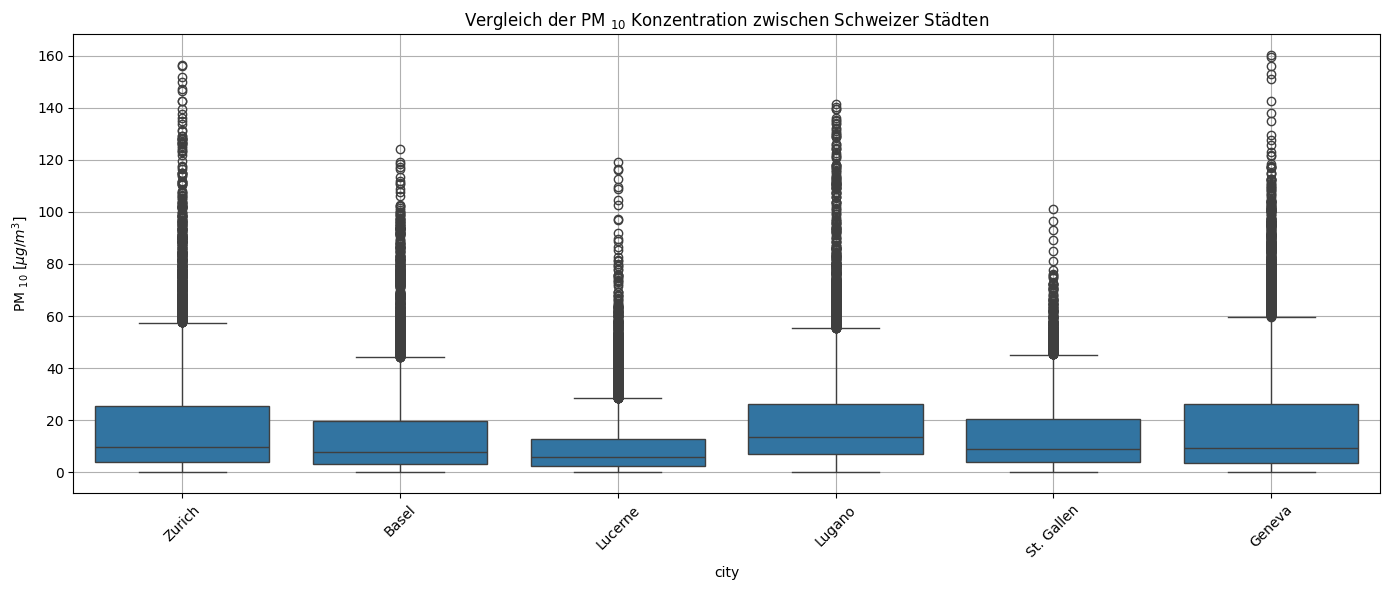

In [15]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=merged_df, x="city", y="pm_coarse")
plt.title(r"Vergleich der PM $_{10}$ Konzentration zwischen Schweizer Städten")
plt.ylabel(r"PM $_{10}$ [$\mu g/m^3$]")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.savefig("plots/boxplot_pm10_city_comparison.jpg", format="jpg", dpi=300, bbox_inches="tight")
plt.show()


#### Beschreibung des PM<sub>10</sub>-Boxplots

Die folgende Grafik zeigt einen Vergleich der stündlichen PM<sub>10</sub>-Konzentrationen in sechs ausgewählten Schweizer Städten anhand von Boxplots. Diese Darstellungsform ermöglicht eine übersichtliche Einschätzung der Verteilung, der zentralen Tendenz, der Streuung sowie möglicher Extremwerte der Feinstaubbelastung.

Die Medianwerte der stündlichen PM<sub>10</sub>-Konzentrationen liegen in den betrachteten Städten überwiegend in einem moderaten Bereich. Dabei ist jedoch zu beachten, dass es sich um Medianwerte stündlicher Messungen handelt. Sie sind daher nicht direkt mit WHO-Richtwerten vergleichbar, da diese sich auf Jahresmittelwerte beziehungsweise 24-Stunden-Mittelwerte beziehen.

Luzern hebt sich durch die niedrigsten Medianwerte und eine vergleichsweise geringe Streuung innerhalb des Interquartilbereichs hervor. Dies deutet auf eine insgesamt tiefere und stabilere PM<sub>10</sub>-Belastung hin. Lugano weist dagegen höhere zentrale Werte sowie eine grössere Variabilität innerhalb der mittleren 50 % der Daten auf.

Auch Genf und Zürich zeigen vergleichsweise höhere PM<sub>10</sub>-Werte und zahlreiche Ausreisser nach oben. Besonders in Genf treten einzelne sehr hohe Spitzenwerte auf. Basel und St. Gallen liegen hinsichtlich Median und Streuung eher im mittleren Bereich der untersuchten Städte.

Auffällig ist, dass alle Städte einzelne Stunden oder Episoden mit deutlich erhöhten PM<sub>10</sub>-Konzentrationen aufweisen. Diese kurzfristigen Spitzen können aus gesundheitlicher Sicht relevant sein, lassen sich aus dem Boxplot allein jedoch nicht eindeutig einer bestimmten Ursache zuordnen.

Insgesamt zeigt sich bei PM<sub>10</sub> ein ähnliches Muster wie bei PM<sub>2.5</sub>: Die zentrale Belastung unterscheidet sich zwischen den Städten nur begrenzt, während vor allem die Ausreisser und die Streuung auf wiederkehrende Episoden erhöhter Feinstaubbelastung hinweisen. Mögliche Einflussfaktoren sind meteorologische Bedingungen, Verkehr, Heizquellen, lokale Emissionssituationen sowie der Ferntransport von Partikeln.


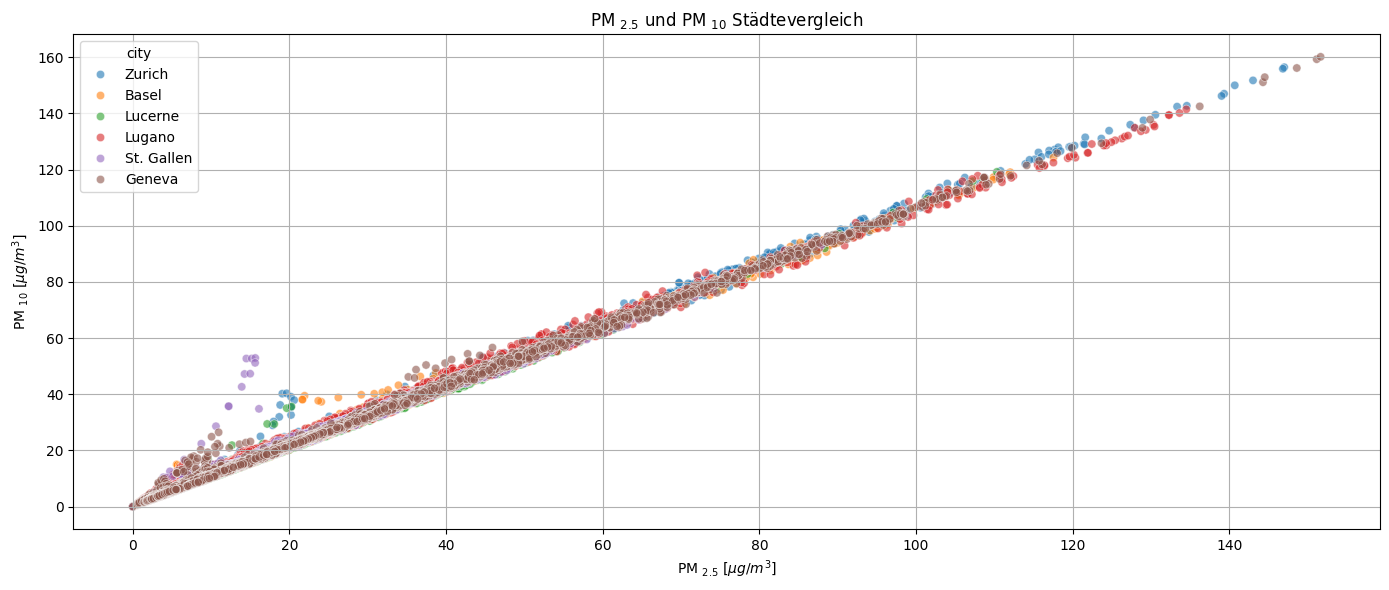

In [16]:
plt.figure(figsize=(14, 6))
sns.scatterplot(data=merged_df, x="pm_fine", y="pm_coarse", hue="city", alpha=0.6)
plt.title(r"PM $_{2.5}$ und PM $_{10}$ Städtevergleich")
plt.xlabel(r"PM $_{2.5}$ [$\mu g/m^3$]")
plt.ylabel(r"PM $_{10}$ [$\mu g/m^3$]")
plt.grid()
plt.tight_layout()
plt.savefig("plots/scatter_pm25_pm10_city_comparison.jpg", format="jpg", dpi=300, bbox_inches="tight")
plt.show()


#### Beschreibung des Streudiagramms

Das folgende Streudiagramm zeigt den Zusammenhang zwischen den Feinstaubkonzentrationen von PM<sub>2.5</sub> und PM<sub>10</sub> in verschiedenen Schweizer Städten.

Über alle Städte hinweg ist ein ausgeprägter positiver linearer Zusammenhang zwischen den beiden Partikelfraktionen erkennbar. Das bedeutet: Höhere Konzentrationen von PM<sub>2.5</sub> gehen in der Regel mit höheren Konzentrationen von PM<sub>10</sub> einher, und umgekehrt. Die Datenpunkte liegen eng entlang einer ansteigenden gedachten Regressionslinie, was auf eine starke Korrelation hinweist. Dieses Muster ist erwartungsgemäss, da PM<sub>2.5</sub> definitionsgemäss eine Teilmenge von PM<sub>10</sub> darstellt.

Obwohl die Punkte farblich nach Städten unterschieden sind, bewegen sich alle Städte entlang desselben allgemeinen Trends. Es sind keine klar abgegrenzten Cluster oder systematisch unterschiedlichen Steigungen zwischen den Städten erkennbar. Dies deutet darauf hin, dass das Verhältnis von PM<sub>2.5</sub> zu PM<sub>10</sub> unter vergleichbaren Bedingungen in allen untersuchten Städten ähnlich ist.

Auffällig ist, dass bei sehr niedrigen Konzentrationen die Streuung etwas grösser wird. Insbesondere einige Datenpunkte aus St. Gallen liegen weiter vom Haupttrend entfernt. Dies könnte auf einen vergleichsweise höheren Anteil gröberer Partikel bei insgesamt niedriger Feinstaubbelastung hindeuten oder auf eine erhöhte Messunsicherheit im unteren Konzentrationsbereich.

Bei hohen Konzentrationen hingegen scheint PM<sub>2.5</sub> einen dominierenden Anteil an der Gesamtbelastung mit PM<sub>10</sub> zu haben, was sich in der engeren Bündelung der Punkte entlang der Hauptlinie widerspiegelt.


### Temperatur Zusammenhang mit Feinstaubkonzentrationen

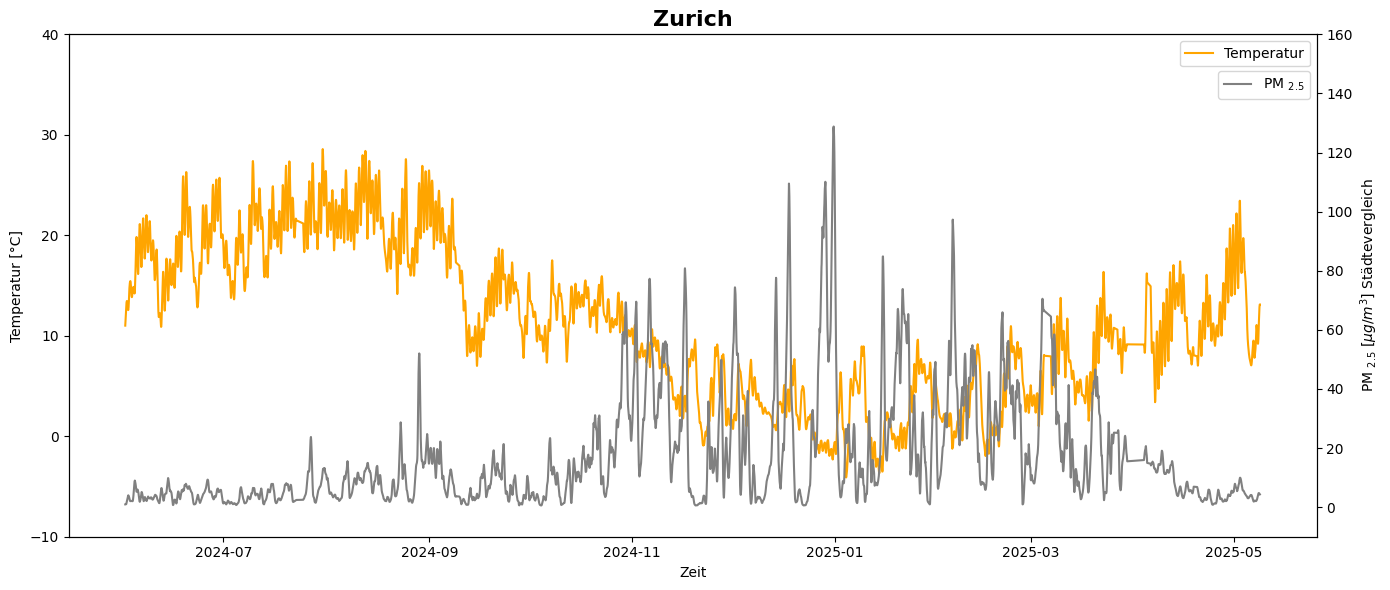

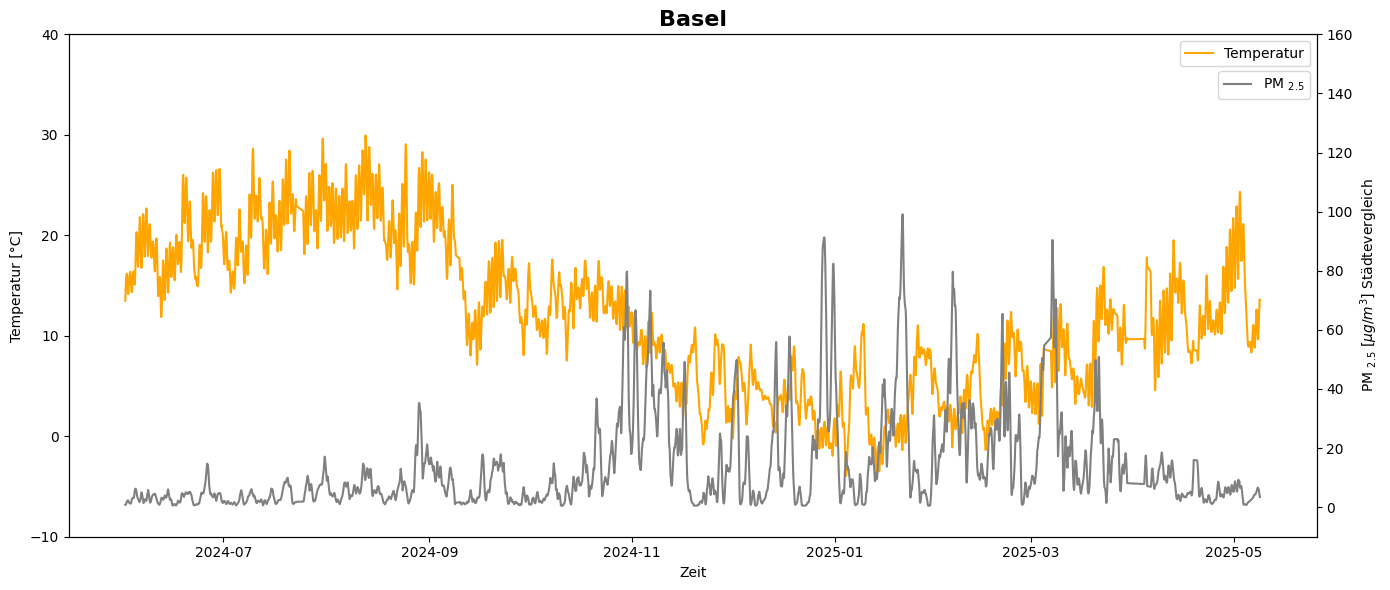

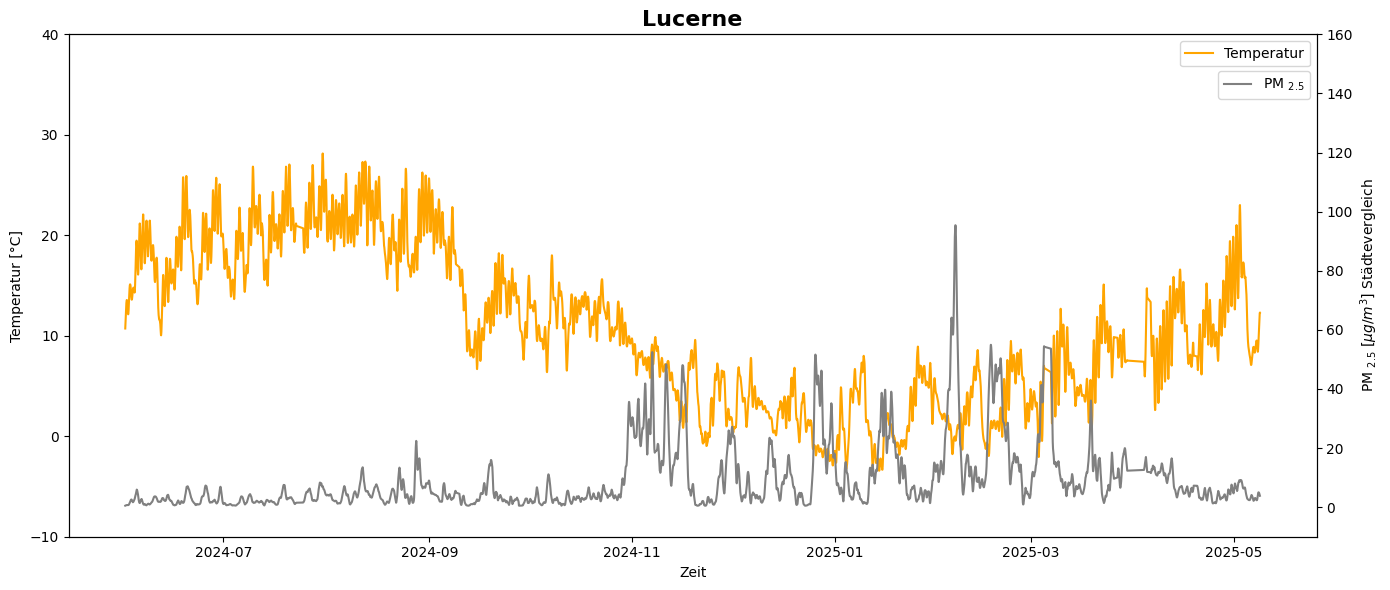

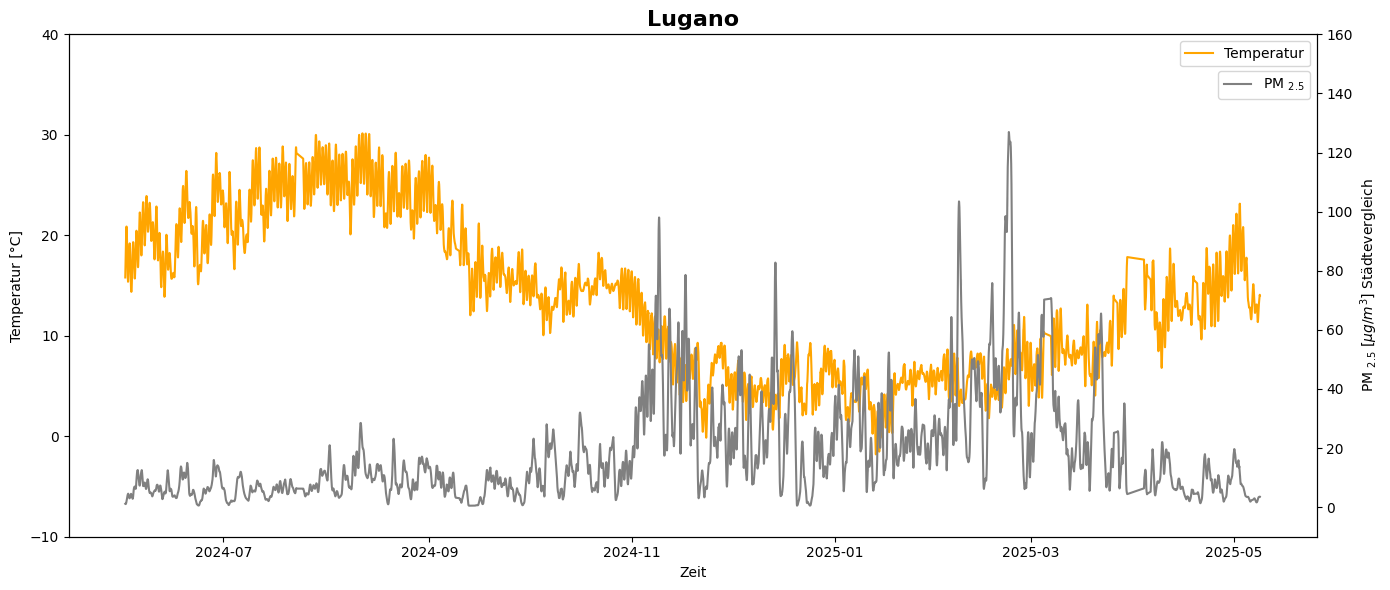

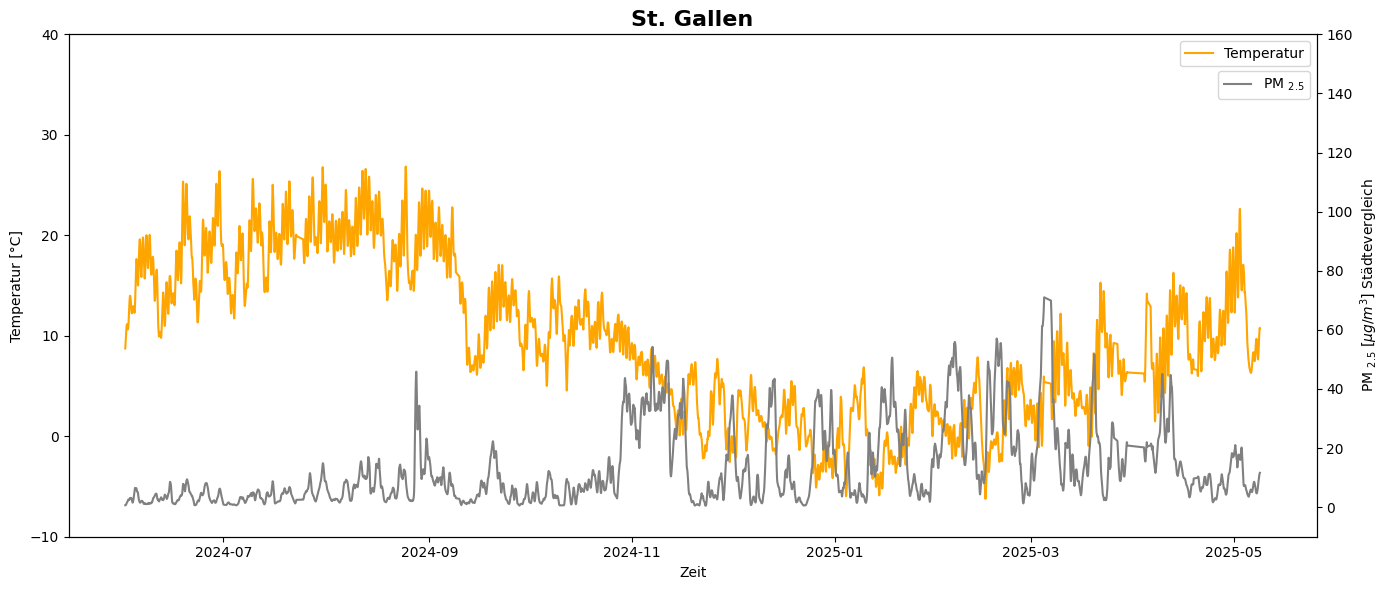

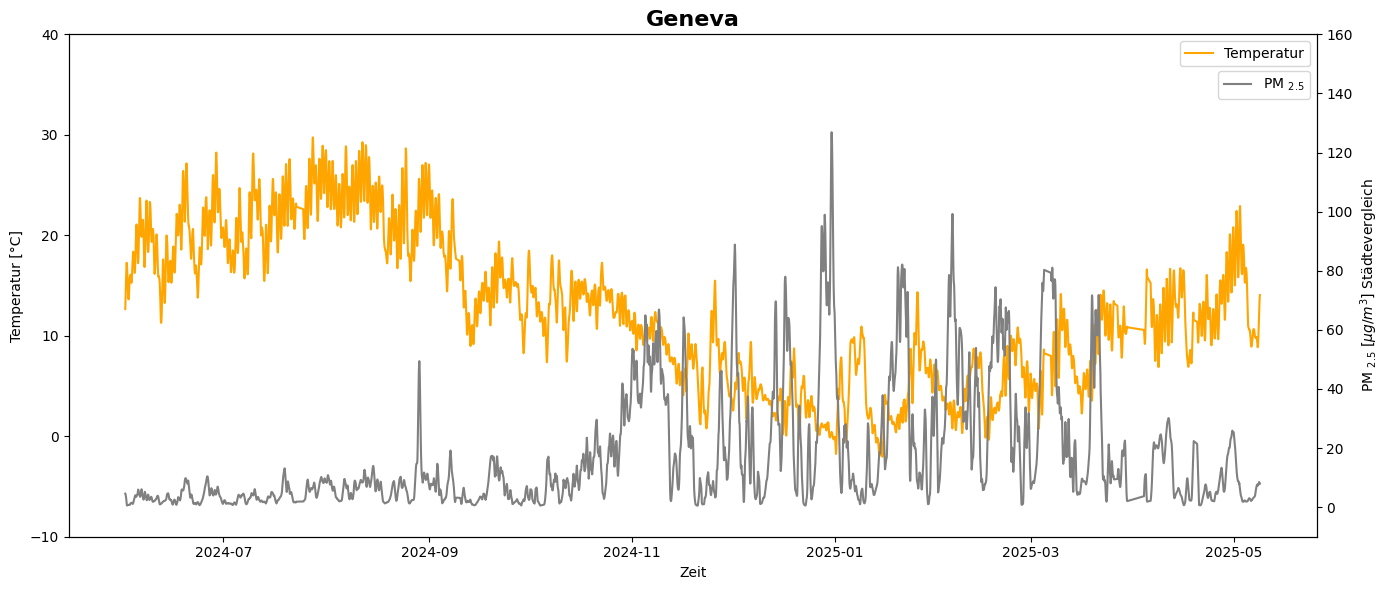

In [17]:
for (city, df) in zip(cities, merged):
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax1.set_title(f"{city}", fontsize=16, fontweight="bold")

    # Glätten der Temperaturdaten mit gleitendem Mittel
    df["temp_smoothed"] = df["temperature"].rolling(window=WINDOW_SIZE).mean()
    sns.lineplot(data=df, x="timestamp", y="temp_smoothed", ax=ax1, color="orange", label="Temperatur")
    ax1.set_ylabel("Temperatur [°C]")
    ax1.set_ylim(TEMP_MIN, TEMP_MAX)

    # Zweite y-Achse für PM2.5-Werte
    ax2 = ax1.twinx()
    df["pm_fine_smoothed"] = df["pm_fine"].rolling(window=WINDOW_SIZE).mean()
    sns.lineplot(data=df, x="timestamp", y="pm_fine_smoothed", ax=ax2, color="grey", label=r"PM $_{2.5}$")
    ax2.set_ylabel(r"PM $_{2.5}$ [$\mu g/m^3$] Städtevergleich")
    ax2.set_ylim(PM_MIN, PM_MAX)
    
    ax1.legend(loc="upper right", bbox_to_anchor=(1, 1))
    ax2.legend(loc="upper right", bbox_to_anchor=(1, 0.94))

    ax1.set_xlabel("Zeit")
    plt.tight_layout()
   
    filename = make_safe_filename(city, "temperature", folder="plots") + ".jpg"
    plt.savefig(filename, format="jpg", dpi=300)

#### Beschreibung der Graphen: Temperatur und PM<sub>2.5</sub>

Die dargestellten Graphen zeigen den zeitlichen Verlauf der Temperatur sowie der PM<sub>2.5</sub>-Konzentrationen (graue Linie) in verschiedenen Schweizer Städten im Zeitraum von Mitte 2024 bis Mitte 2025.

Die orange Linie stellt den saisonalen Verlauf der Temperatur dar. Dabei zeigt sich ein klarer Zusammenhang zwischen der Lufttemperatur und der Feinstaubbelastung: Während der Sommermonate sind die PM<sub>2.5</sub>-Konzentrationen vergleichsweise niedrig. Ab Oktober/November, mit sinkenden Temperaturen, ist ein Anstieg der PM<sub>2.5</sub>-Werte erkennbar, sowohl hinsichtlich der Grundbelastung als auch in der Häufigkeit und Intensität der Spitzenwerte. Die höchsten Konzentrationen treten typischerweise in den Wintermonaten auf. Im Frühjahr nehmen sowohl die Durchschnittswerte als auch die Extrembelastungen wieder ab.

Dieses saisonale Muster bestätigt die zuvor beobachteten Ergebnisse der Korrelationsanalyse: Es besteht ein inverser Zusammenhang zwischen der Temperatur und den PM<sub>2.5</sub>-Konzentrationen.

Die Ursachen für erhöhte Feinstaubbelastungen im Winter sind vielfältig. Zum einen führt der gesteigerte Energiebedarf in der kalten Jahreszeit zu vermehrtem Heizen, was insbesondere bei Einsatz fossiler Brennstoffe zur Emission von Feinstaub beiträgt. Zum anderen begünstigen meteorologische Bedingungen wie Inversionslagen eine stabile Schichtung der Luft, wodurch die vertikale Durchmischung gehemmt wird und Schadstoffe in Bodennähe akkumulieren können. Zusätzlich kann auch ein verändertes Mobilitätsverhalten, etwa vermehrte Nutzung von privaten Fahrzeugen im Winter, zu höheren Emissionen beitragen.

Zusammenfassend zeigt sich, dass die Lufttemperatur ein signifikanter Einflussfaktor auf die Feinstaubbelastung darstellt. Die PM<sub>2.5</sub>-Werte unterliegen einem deutlichen saisonalen Trend, mit erhöhten Konzentrationen in den kälteren Monaten des Jahres.


### Regen Zusammenhang mit Feinstaubkonzentrationen

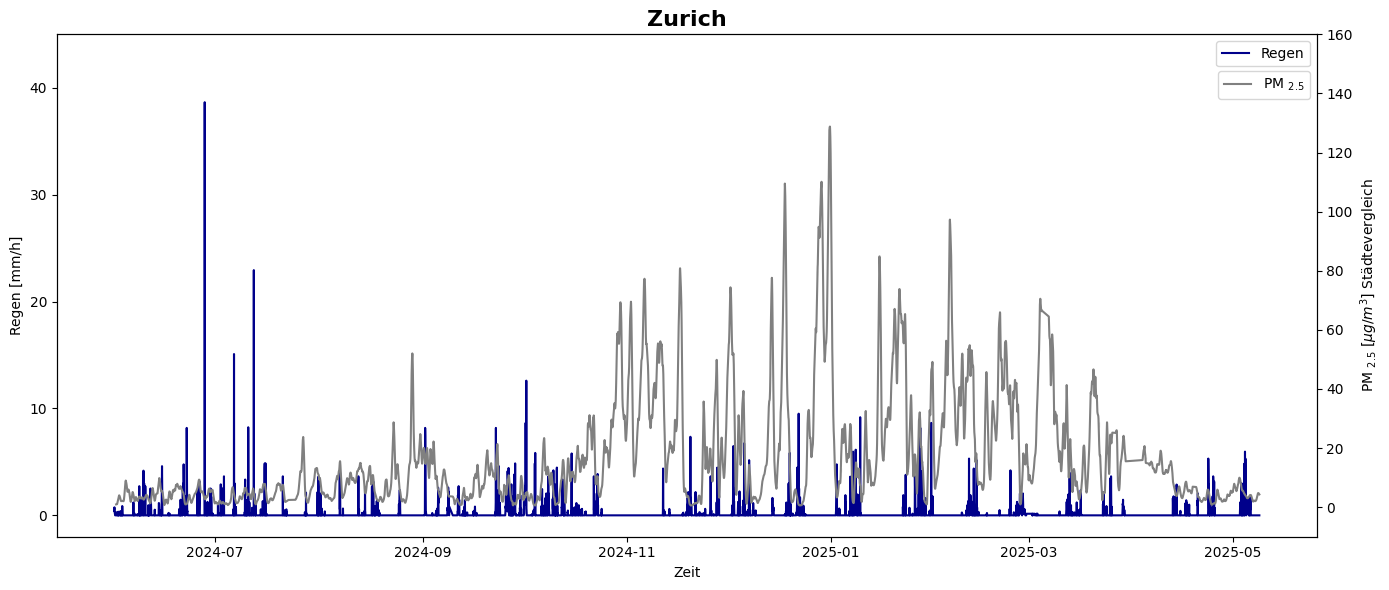

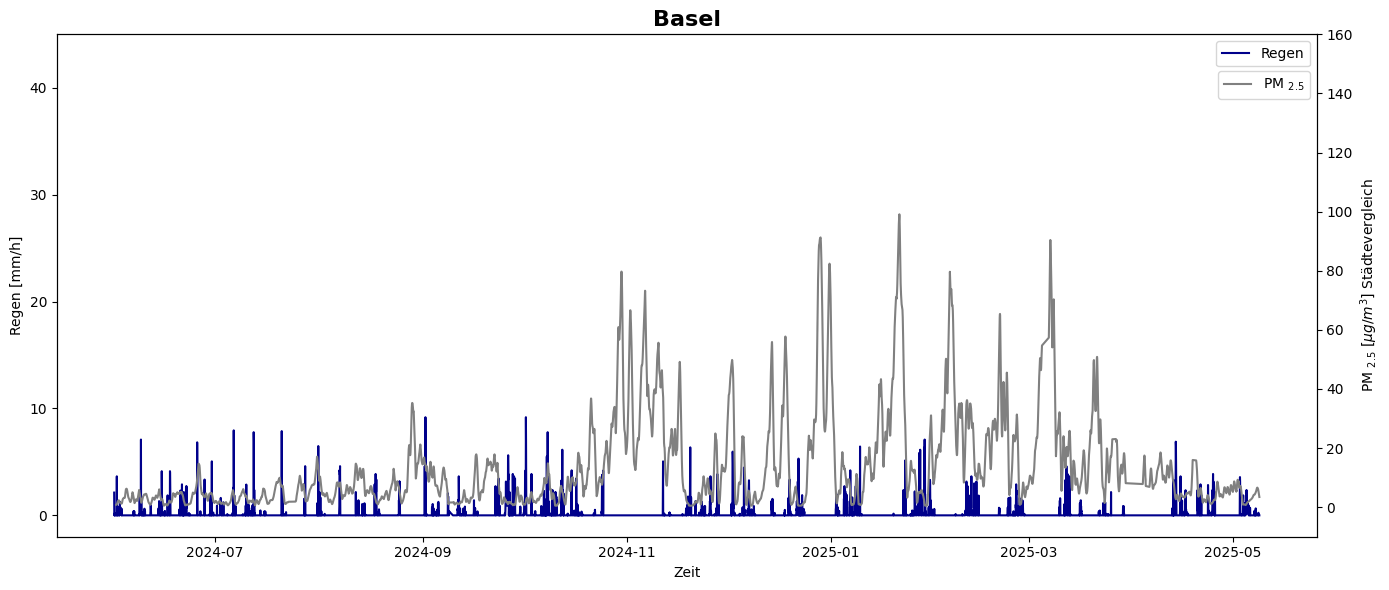

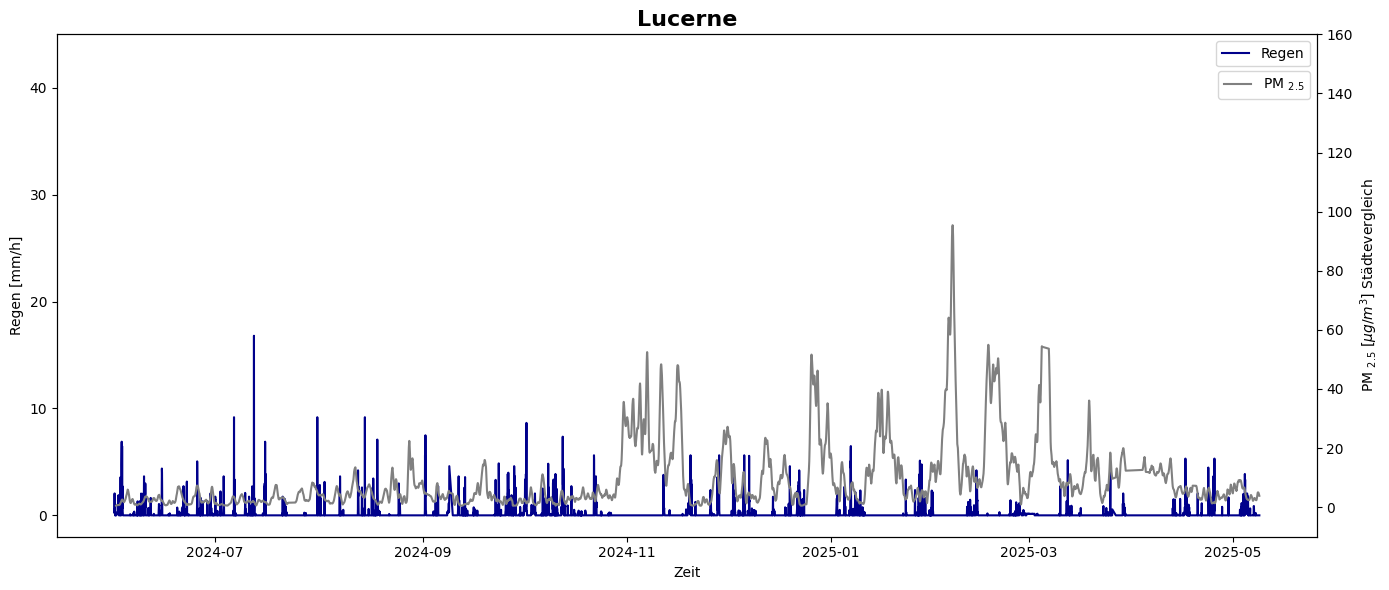

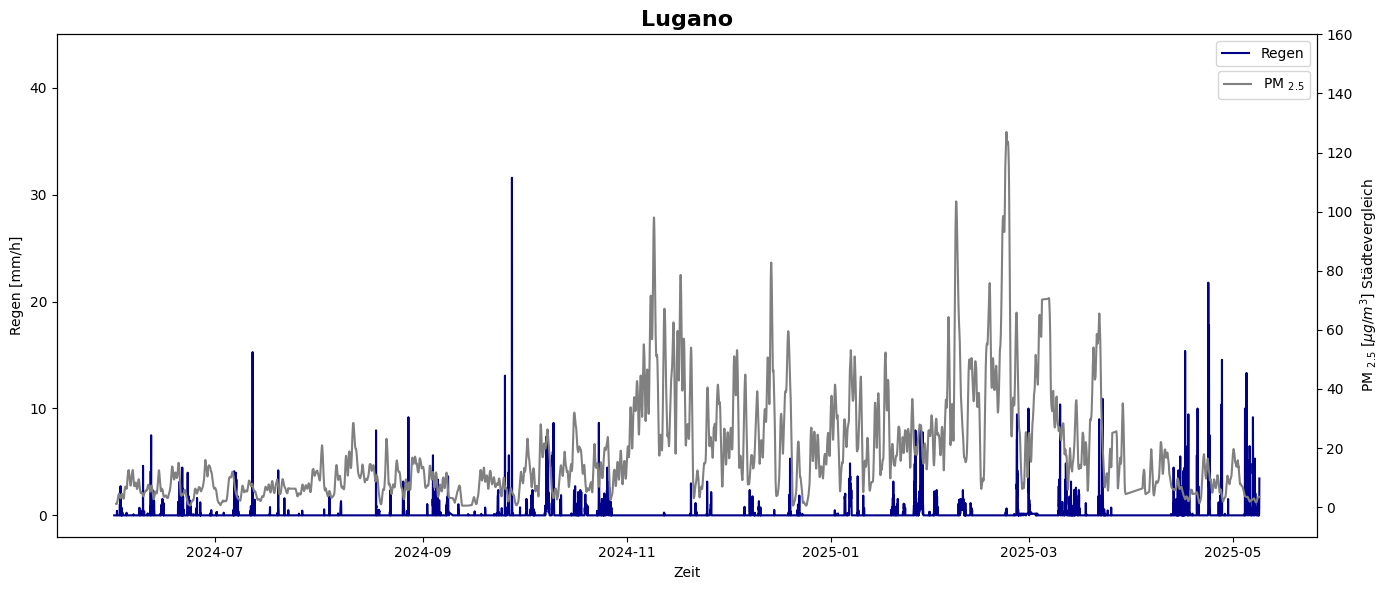

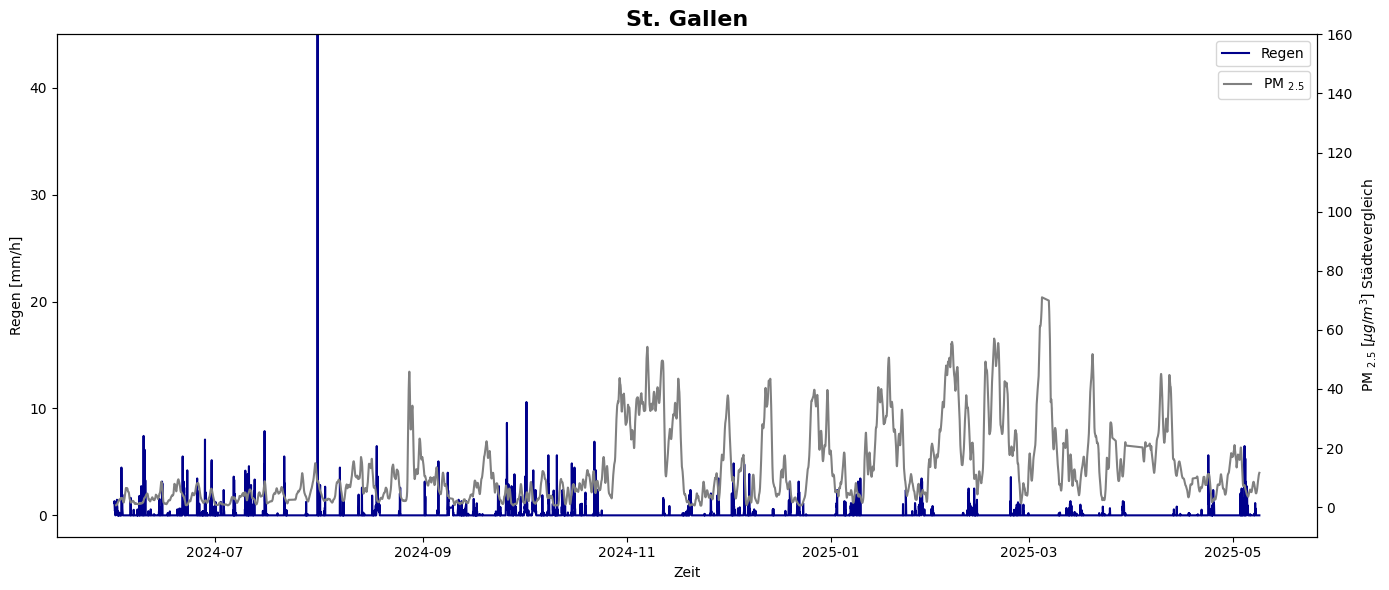

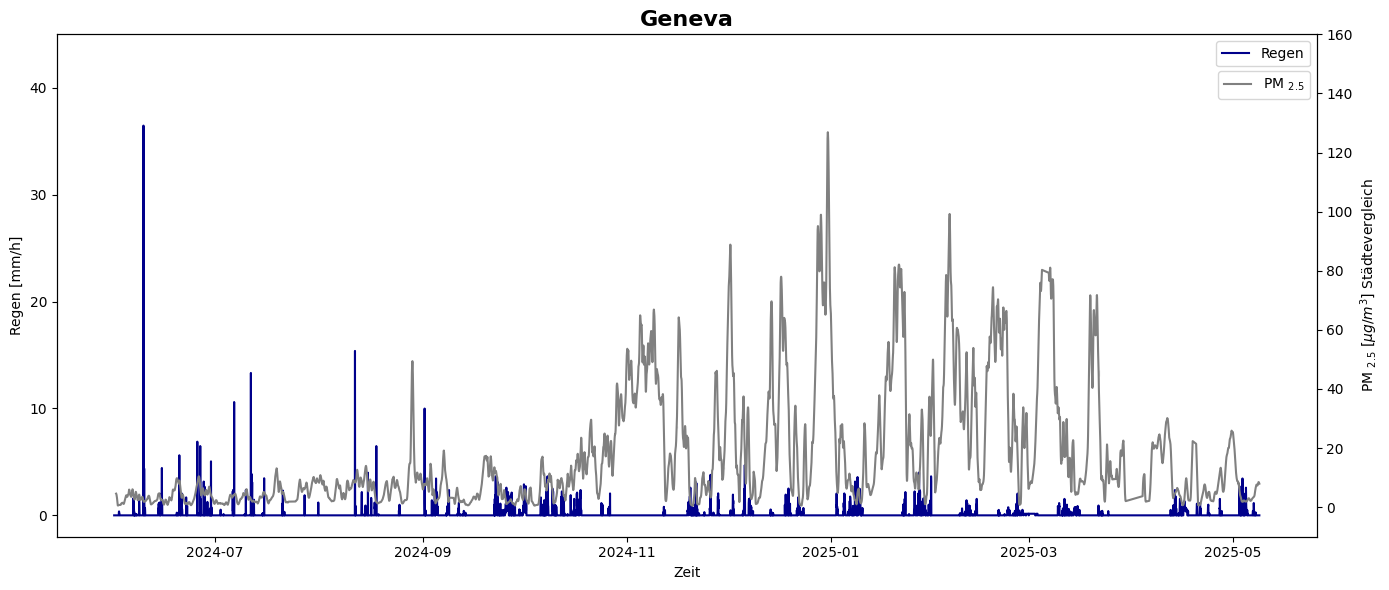

In [18]:
for (city, df) in zip(cities, merged):
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax1.set_title(f"{city}", fontsize=16, fontweight="bold")

    sns.lineplot(data=df, x="timestamp", y="rain", ax=ax1, color="darkblue", label="Regen")
    ax1.set_ylabel("Regen [mm/h]")
    ax1.set_ylim(RAIN_MIN, RAIN_MAX)

    ax2 = ax1.twinx()
    df["pm_fine_smoothed"] = df["pm_fine"].rolling(window=WINDOW_SIZE).mean()
    sns.lineplot(data=df, x="timestamp", y="pm_fine_smoothed", ax=ax2, color="grey", label=r"PM $_{2.5}$")
    ax2.set_ylabel(r"PM $_{2.5}$ [$\mu g/m^3$] Städtevergleich")
    ax2.set_ylim(PM_MIN, PM_MAX)
    
    ax1.legend(loc="upper right", bbox_to_anchor=(1, 1))
    ax2.legend(loc="upper right", bbox_to_anchor=(1, 0.94))

    ax1.set_xlabel("Zeit")
    plt.tight_layout()
    filename = make_safe_filename(city, "rain", folder="plots") + ".jpg"
    plt.savefig(filename, format="jpg", dpi=300)

#### Beschreibung der Graphen: Regen und PM<sub>2.5</sub>

Die dargestellten Graphen zeigen den zeitlichen Verlauf des Niederschlags (dunkelblaue Linie) sowie der PM<sub>2.5</sub>-Konzentrationen (graue Linie) in verschiedenen Schweizer Städten im Zeitraum von etwa Mitte 2024 bis Mitte 2025.

Regenereignisse treten über das gesamte Jahr hinweg in unregelmässigen Abständen auf. Es sind sowohl intensive Niederschlagsereignisse (ausgeprägte blaue Spitzen) als auch längere Trockenphasen ohne nennenswerte Regenmengen zu beobachten. Da in diesen Plots die PM<sub>2.5</sub>-Verläufe bereits aus dem Zusammenhang mit der Temperatur bekannt sind, wird hier der Fokus primär auf den Einfluss des Regens gelegt.

Bei genauer Betrachtung lässt sich stellenweise ein sogenannter Auswascheffekt erkennen: In Phasen mit erhöhten PM<sub>2.5</sub>-Konzentrationen, insbesondere während der Wintermonate, führen einsetzende Regenereignisse häufig zu einem Rückgang der Feinstaubbelastung. Dieser reinigende Effekt entsteht dadurch, dass Regentropfen Partikel aus der Luft binden und zur Bodenoberfläche transportieren. Der Effekt ist jedoch nicht durchgehend ausgeprägt: Leichte oder sehr kurzzeitige Regenereignisse scheinen in vielen Fällen nicht auszureichen, um die Partikelkonzentration signifikant zu reduzieren. Zudem können die PM<sub>2.5</sub>-Werte bei stabilen meteorologischen Bedingungen unmittelbar nach dem Regen wieder ansteigen.

Dieser visuelle Eindruck steht im Einklang mit den Ergebnissen der zuvor durchgeführten Korrelationsanalyse: Der Zusammenhang zwischen Regen und PM<sub>2.5</sub> ist insgesamt nur schwach negativ ausgeprägt, mit Korrelationskoeffizienten typischerweise im Bereich von −0.05 bis −0.1. Dies weist darauf hin, dass der reinigende Effekt des Regens zwar vorhanden, jedoch nicht systematisch und konsistent stark genug ist, um einen hohen linearen Zusammenhang über den gesamten Zeitraum hinweg statistisch abzubilden.

Die Ursache hierfür liegt in der Natur des Niederschlagsgeschehens und seiner Wirkung: Der Einfluss hängt stark von der Intensität, Dauer und den meteorologischen Rahmenbedingungen ab. Kurze oder schwache Regenfälle haben nur begrenzte Effekte, während starke und anhaltende Niederschläge deutlich wirksamer sein können. Darüber hinaus ist die Wirkung oft zeitverzögert oder durch andere wetterbedingte Faktoren überlagert, was die lineare Korrelation abschwächt.

Insgesamt lässt sich festhalten, dass Regen eine tendenziell luftreinigende Wirkung auf PM<sub>2.5</sub> besitzt, dieser Zusammenhang jedoch in aggregierten statistischen Analysen nur schwach zum Ausdruck kommt, da viele weitere Einflussgrössen gleichzeitig wirken.

### Windgeschwindigkeit Zusammenhang mit Feinstaubkonzentrationen

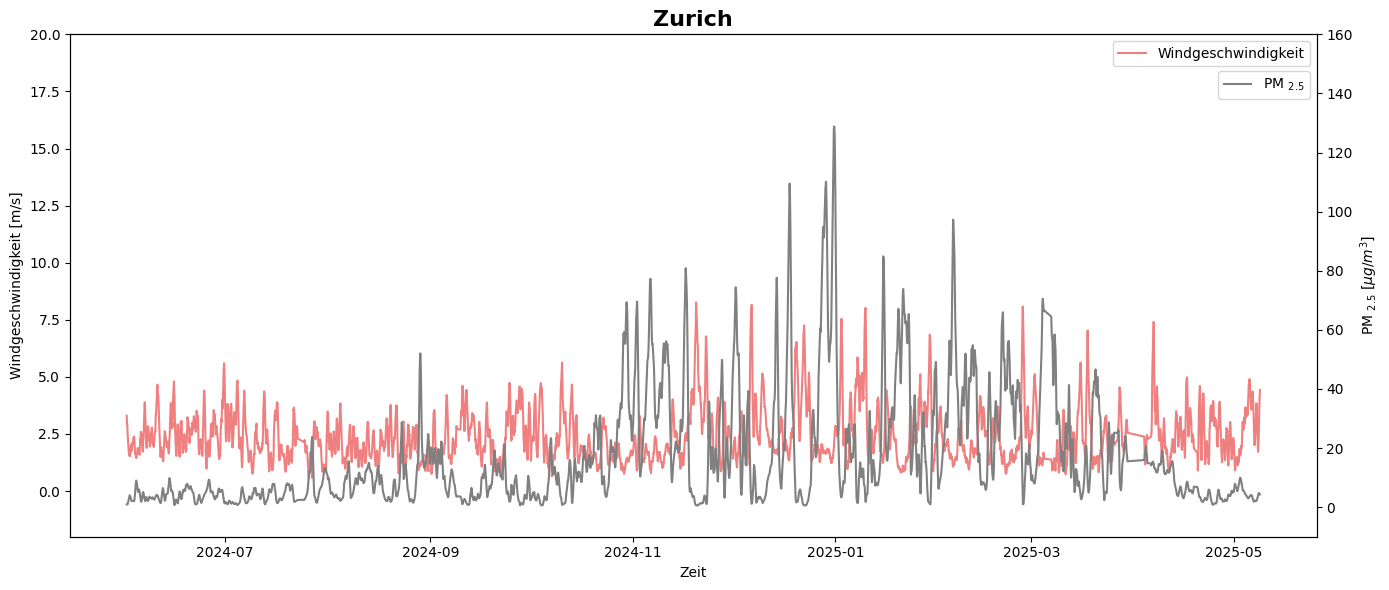

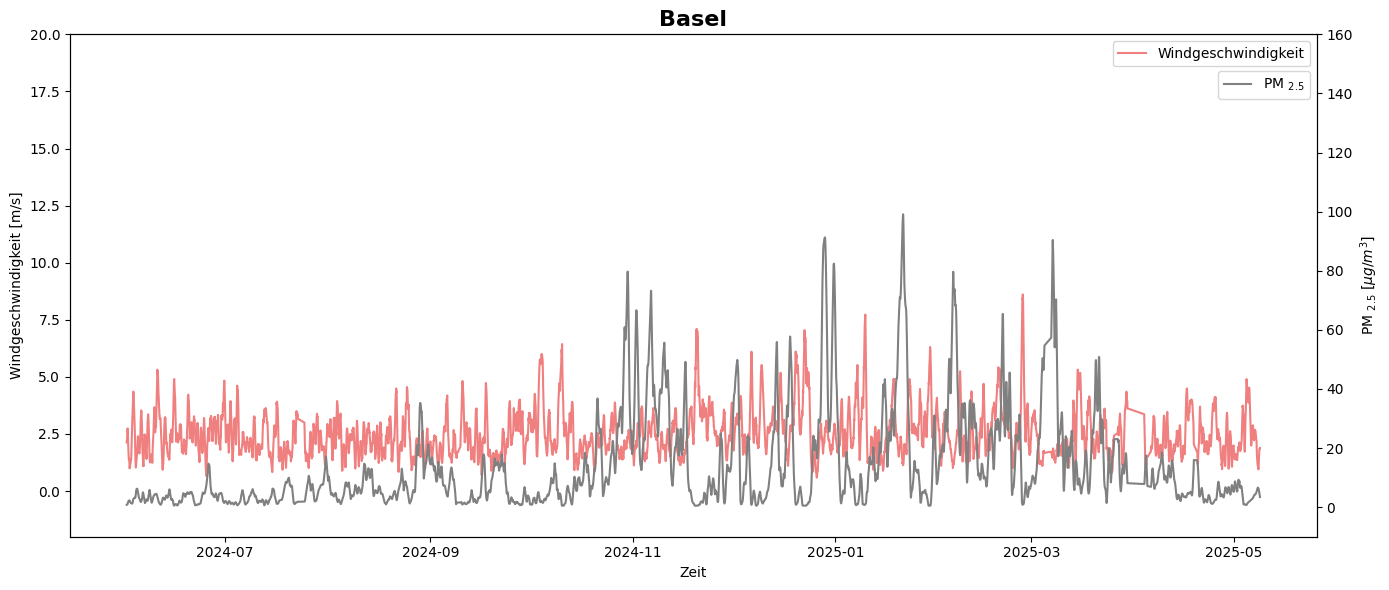

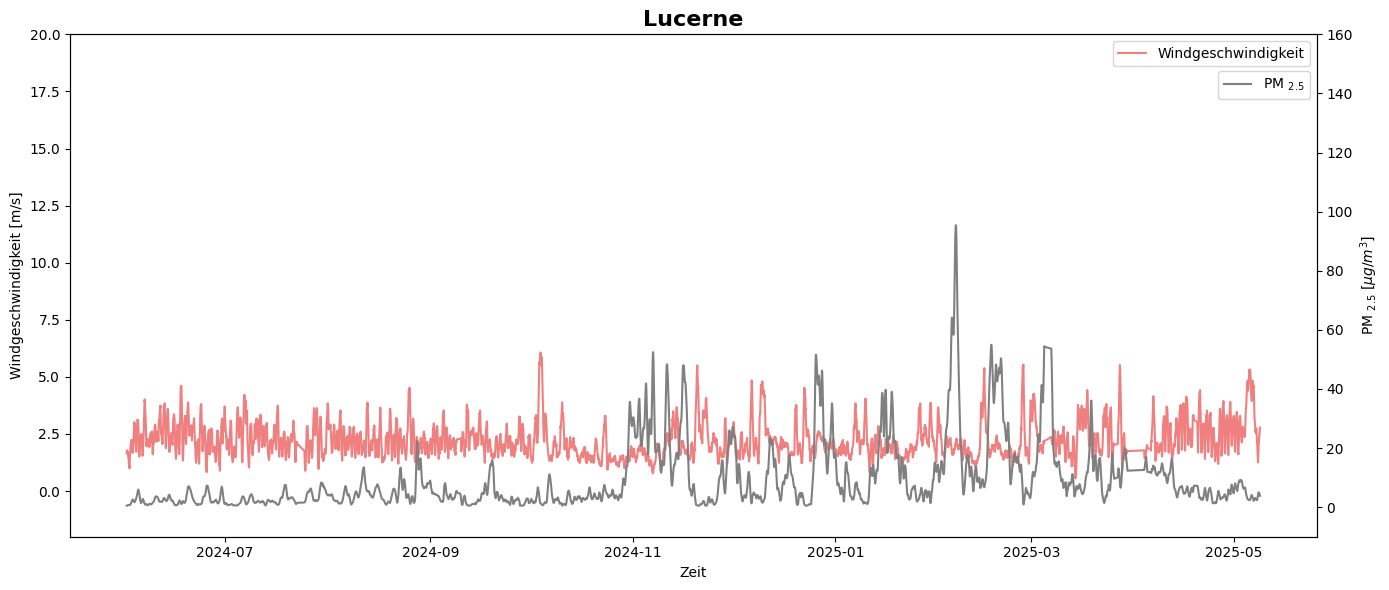

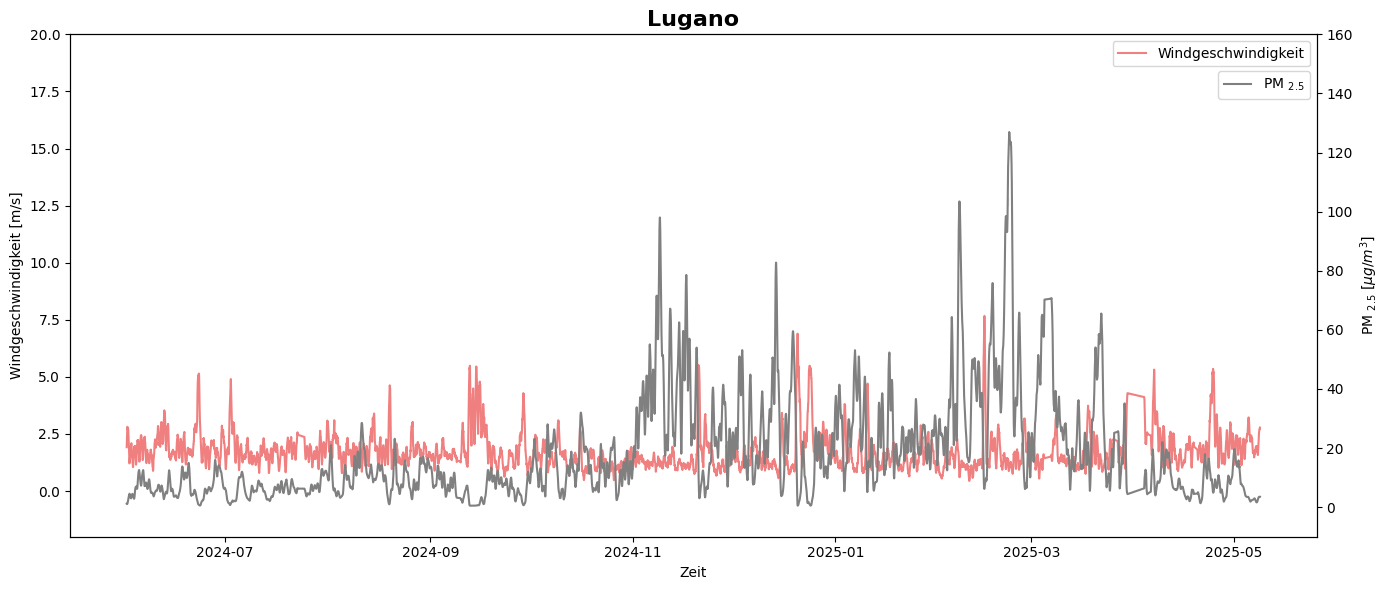

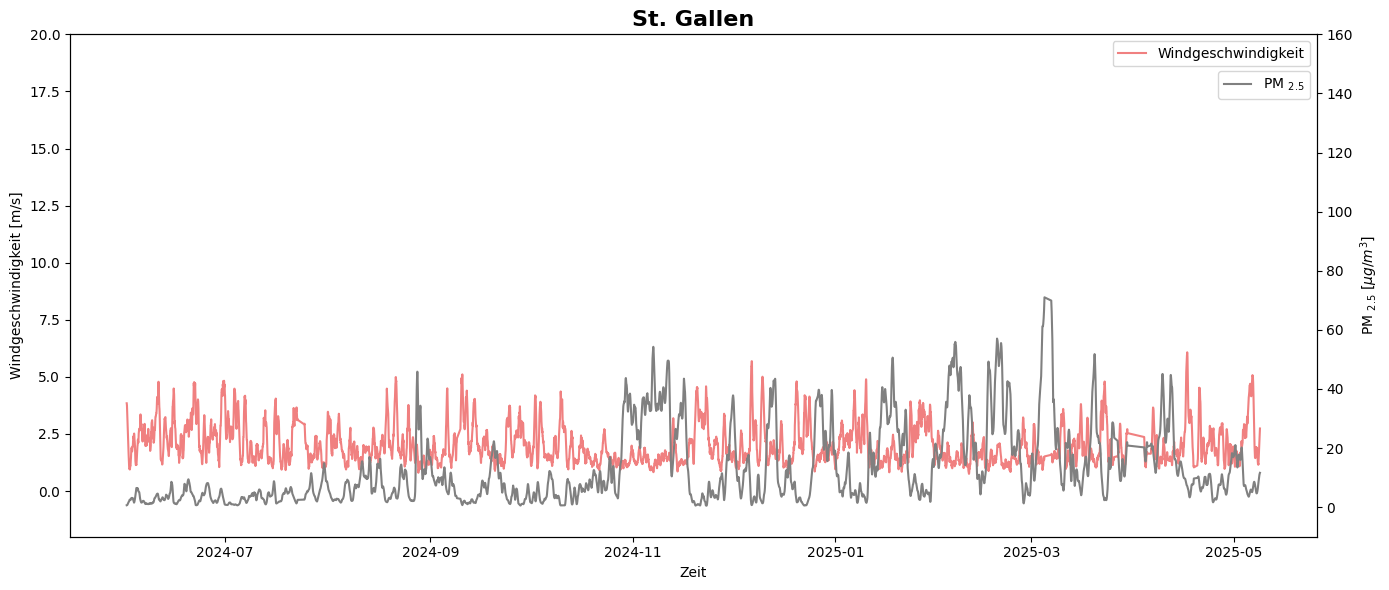

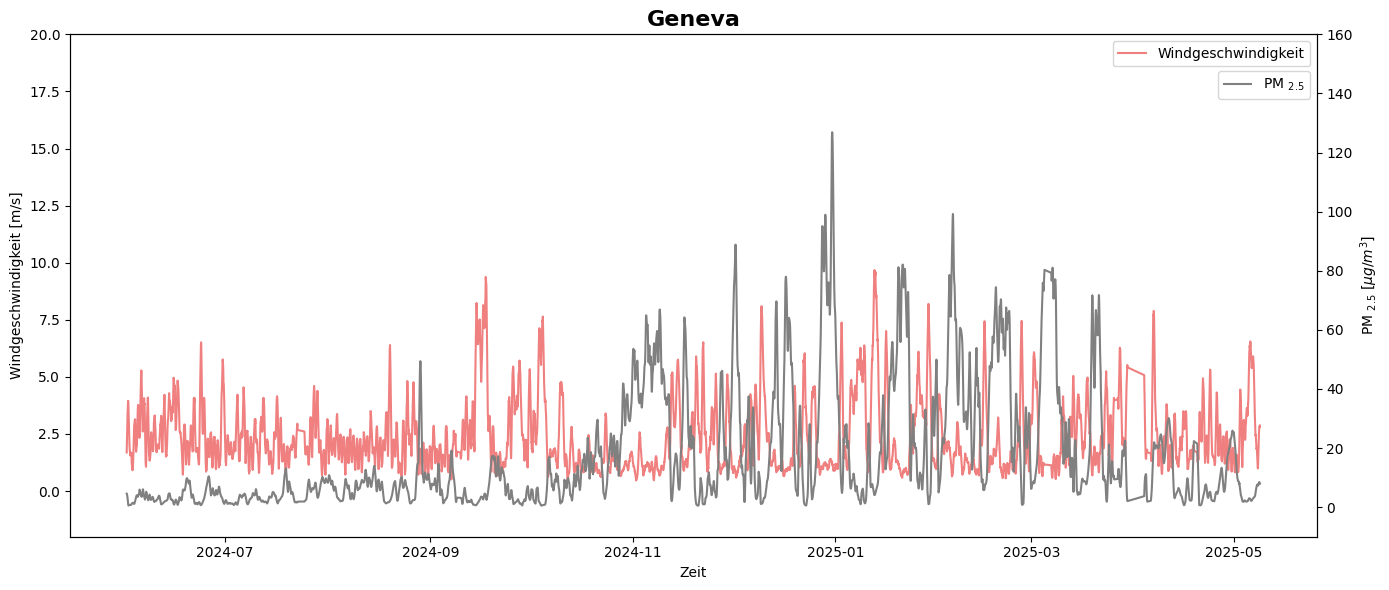

In [19]:
for (city, df) in zip(cities, merged):
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax1.set_title(f"{city}", fontsize=16, fontweight="bold")

    df["wind_speed_smoothed"] = df["wind_speed"].rolling(window=WINDOW_SIZE).mean()
    sns.lineplot(data=df, x="timestamp", y="wind_speed_smoothed", ax=ax1, color="lightcoral", label="Windgeschwindigkeit")
    ax1.set_ylabel("Windgeschwindigkeit [m/s]")
    ax1.set_ylim(WIND_MIN, WIND_MAX)

    ax2 = ax1.twinx()
    
    df["pm_fine_smoothed"] = df["pm_fine"].rolling(window=WINDOW_SIZE).mean()
    sns.lineplot(data=df, x="timestamp", y="pm_fine_smoothed", ax=ax2, color="grey", label=r"PM $_{2.5}$")
    ax2.set_ylabel(r"PM $_{2.5}$ [$\mu g/m^3$]")
    ax2.set_ylim(PM_MIN, PM_MAX)
    
    ax1.legend(loc="upper right", bbox_to_anchor=(1, 1))
    ax2.legend(loc="upper right", bbox_to_anchor=(1, 0.94))

    ax1.set_xlabel("Zeit")
    plt.tight_layout()
    filename = make_safe_filename(city, "wind", folder="plots") + ".jpg"
    plt.savefig(filename, format="jpg", dpi=300, bbox_inches="tight")
    plt.show()


#### Beschreibung der Graphen: Wind und PM<sub>2.5</sub>

Die dargestellten Graphen zeigen den zeitlichen Verlauf der Windgeschwindigkeit (rote Linie) sowie der PM<sub>2.5</sub>-Konzentrationen (graue Linie) in verschiedenen Schweizer Städten im Zeitraum von Mitte 2024 bis Mitte 2025.

Die Windgeschwindigkeit weist über das gesamte Jahr hinweg eine starke Variabilität auf. Es lassen sich sowohl Phasen mit anhaltend schwachem Wind als auch solche mit häufigeren und stärkeren Windereignissen beobachten. Ein klarer saisonaler Trend ist in den Windverläufen jedoch nicht ersichtlich, vielmehr schwankt die Windgeschwindigkeit kontinuierlich, unabhängig von der Jahreszeit.

Bei näherer Betrachtung zeigt sich insbesondere in den Wintermonaten ein deutlicher inverser Zusammenhang zwischen der Windgeschwindigkeit und den PM<sub>2.5</sub>-Werten. In Perioden mit schwachem Wind steigen die Feinstaubkonzentrationen häufig stark an, teilweise bis in sehr hohe Belastungsbereiche. Umgekehrt ist nach einem Anstieg der Windgeschwindigkeit häufig ein Rückgang der PM<sub>2.5</sub>-Konzentrationen zu beobachten. Dies lässt sich durch den physikalischen Effekt erklären, dass Wind zur Verdünnung und zum Abtransport von Luftschadstoffen beiträgt. Unter Schwachwindbedingungen hingegen verbleiben die Schadstoffe länger in Bodennähe und können sich anreichern.

Diese Beobachtungen decken sich mit den Ergebnissen der Korrelationsanalyse: Die berechneten Korrelationskoeffizienten zwischen Windgeschwindigkeit und PM<sub>2.5</sub> liegen in einem moderat negativen Bereich von −0.15 bis −0.4, abhängig von der Stadt. Dies weist auf einen statistisch relevanten, wenn auch nicht starken linearen Zusammenhang hin. Der Effekt ist konsistent, aber nicht perfekt linear, was aufgrund der Komplexität atmosphärischer Prozesse zu erwarten ist.

Insgesamt unterstreichen die Graphen, dass die Windgeschwindigkeit eine entscheidende Rolle für die Luftqualität spielt. Sie wirkt als regulierender Faktor für die Feinstaubkonzentration, insbesondere bei ansonsten ungünstigen Bedingungen wie im Winter. Die kombinierte Analyse aus Zeitreihe und Korrelation zeigt, dass niedrige Windgeschwindigkeiten regelmässig mit hohen PM<sub>2.5</sub>-Belastungen einhergehen, während höhere Windgeschwindigkeiten zur Verbesserung der Luftqualität beitragen.


## Fazit

Die Analyse der Feinstaubkonzentrationen (PM<sub>2.5</sub> und PM<sub>10</sub>) in den untersuchten Schweizer Städten zeigt ein differenziertes Bild der Luftqualität. Insgesamt liegen die zentralen Werte in Städten wie Luzern und St. Gallen tendenziell niedriger, während alle betrachteten Städte einzelne Episoden mit deutlich erhöhten Belastungswerten aufweisen. Besonders Lugano und Genf fallen durch höhere zentrale Werte sowie eine grössere Variabilität der PM<sub>10</sub>-Werte auf.

Ein klarer positiver Zusammenhang zwischen PM<sub>2.5</sub>- und PM<sub>10</sub>-Konzentrationen ist in allen Städten erkennbar. Dies ist plausibel, da PM<sub>2.5</sub> als feinere Partikelfraktion Teil der PM<sub>10</sub>-Belastung ist und beide Fraktionen häufig durch ähnliche Quellen oder atmosphärische Prozesse beeinflusst werden.

### Saisonale Muster

Die Feinstaubbelastung unterliegt einem deutlichen saisonalen Verlauf. Die höchsten Konzentrationen sowie die häufigsten Spitzenwerte treten vor allem während der Herbst- und Wintermonate auf. In den wärmeren Monaten Frühling und Sommer sinken die Werte deutlich, was unter anderem mit veränderten Emissionsmustern und besserer atmosphärischer Durchmischung zusammenhängen kann.

### Zusammenhang mit meteorologischen Faktoren

- **Temperatur:**  
  Tiefe Temperaturen gehen im betrachteten Zeitraum häufig mit höheren PM-Konzentrationen einher. Mögliche Ursachen sind erhöhter Heizenergiebedarf sowie häufigere Inversionswetterlagen, welche die Durchmischung der Luftmassen hemmen und damit die Anreicherung von Schadstoffen in Bodennähe begünstigen können.

- **Regen:**  
  Niederschlag kann als natürlicher Reinigungsmechanismus der Atmosphäre wirken. In den Daten ist dieser Zusammenhang jedoch nur schwach linear ausgeprägt, da Intensität, Dauer und zeitliche Verzögerung von Regenereignissen eine grosse Rolle spielen.

- **Windgeschwindigkeit:**  
  Wind spielt eine wichtige Rolle bei der Verdünnung und beim Abtransport von Luftschadstoffen. Besonders in den Wintermonaten ist ersichtlich, dass hohe Feinstaubwerte häufig mit Phasen geringer Windgeschwindigkeit zusammenfallen.

### Zusammenfassung

Die Luftqualität in den untersuchten Städten ist das Resultat eines komplexen Zusammenspiels zwischen lokalen Emissionsquellen, überregionalem Schadstoffeintrag und den jeweils herrschenden meteorologischen Bedingungen. Die vorliegenden Boxplots und Zeitreihen zeigen stündliche Messwerte und eignen sich daher vor allem zur Beschreibung von Verteilungen, Mustern und Episoden. Ein direkter Vergleich mit WHO-Jahres- oder Tagesmittelwerten ist nur eingeschränkt möglich und müsste über separat berechnete Jahres- bzw. Tagesmittelwerte erfolgen.


## Ausblick

Die kontinuierliche Überwachung der Luftqualität sowie der relevanten meteorologischen Parameter ist essenziell, um langfristige Entwicklungen zu erkennen, die Wirksamkeit getroffener Massnahmen zu evaluieren und die Bevölkerung bei kritischen Belastungssituationen zeitnah informieren zu können.

Eine nachhaltige Verbesserung der Luftqualität erfordert eine konsequente Reduktion der Emissionen an der Quelle. Besonders emissionsintensive Sektoren wie der Verkehr, Heizsysteme, industrielle Prozesse und bestimmte landwirtschaftliche Praktiken stehen dabei im Fokus. Vor allem während der Wintermonate könnten temporäre Massnahmen bei stabilen Inversionswetterlagen sinnvoll sein, um kurzfristige Spitzenbelastungen zu vermeiden.

Darüber hinaus bieten die beobachteten Ausreisser in den Messdaten Anlass für weiterführende Analysen. So stellt sich die Frage, inwiefern tageszeitliche Schwankungen, geographische Besonderheiten oder infrastrukturelle Gegebenheiten, wie etwa die Nähe zu Flughäfen in Zürich, Genf oder Basel, einen Einfluss auf die Feinstaubkonzentrationen haben. Eine differenzierte Quellenzuordnung von PM<sub>2.5</sub> und PM<sub>10</sub> könnte helfen, gezieltere Massnahmen zur Emissionsminderung zu entwickeln.

### Klimawandel und zukünftige Herausforderungen

Der fortschreitende Klimawandel könnte die Rahmenbedingungen für die Luftqualität in Zukunft deutlich verändern. Milder werdende Winter könnten beispielsweise zu einem geringeren Heizbedarf und somit zu sinkenden Emissionen führen. Gleichzeitig könnten jedoch veränderte atmosphärische Stabilitätsverhältnisse, häufigere Trockenperioden oder Extremwetterereignisse neue Herausforderungen für die Luftreinhaltung mit sich bringen. Auch der Einfluss von Ferntransporten, etwa durch Saharastaub, sollte im Zuge dieser Entwicklungen stärker in den Blick genommen werden.

### Gesellschaftliche Sensibilisierung und Forschung

Ein besseres Verständnis für die Ursachen und gesundheitlichen Auswirkungen von Luftverschmutzung ist auch auf gesellschaftlicher Ebene von Bedeutung. Die Sensibilisierung der Bevölkerung kann zu einem bewussteren Verhalten beitragen, etwa bei der Wahl der Mobilität oder beim Energieverbrauch. Gleichzeitig ist weitere wissenschaftliche Forschung notwendig, insbesondere zur genaueren Bestimmung lokaler und überregionaler Emissionsquellen sowie zur Analyse spezifischer Belastungsepisoden.

Die Luftqualität in Schweizer Städten wird durch ein komplexes Zusammenspiel aus lokalen Emissionen, meteorologischen Bedingungen und überregionalen Einflüssen bestimmt. Während Wetterfaktoren kurzfristige Schwankungen stark beeinflussen, können nachhaltige Verbesserungen langfristig nur durch eine wirksame und konsequente Reduktion der Schadstoffemissionen erreicht werden.

## Quellen
- [Air Pollution History API](https://openweathermap.org/api/air-pollution)
- [historischen OpenWeatherMap-API](https://openweathermap.org/history)
- [Geocoding-API von OpenWeatherMap](https://openweathermap.org/api/geocoding-api)
- [WHO Richtlinie](https://iris.who.int/bitstream/handle/10665/345329/9789240034228-eng.pdf)
- [Definition zu PM2.5 und PM10](https://smartairfilters.com/de/was-ist-der-unterschied-zwischen-pm25-und-pm10-partikel/)  
- [Definition zu PM2.5 und PM10, sowie Gesundheitliche Schäden](https://www.bafu.admin.ch/bafu/de/home/themen/luft/luftbelastung/feinstaub.html)  
- [Meteorologischer Einfluss auf die Feinstaubpartikel](https://www.baden-wuerttemberg.de/fileadmin/redaktion/m-mvi/intern/Dateien/PDF/Luftreinhaltung_Feinstaub-Alarm_DWD_Vorhersagekriterien.pdf)  